# Airline Customer Satisfaction — Exploratory Data Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from math import pi
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titleweight'] = 'bold'

SAT_PALETTE = {'satisfied': '#2ecc71', 'dissatisfied': '#e74c3c'}
CLASS_PALETTE = {'Business': '#3498db', 'Eco': '#e67e22', 'Eco Plus': '#9b59b6'}
TRAVEL_PALETTE = {'Business travel': '#1abc9c', 'Personal Travel': '#e74c3c'}
CUST_PALETTE = {'Loyal Customer': '#3498db', 'disloyal Customer': '#e67e22'}

SERVICE_COLS = [
    'Seat comfort', 'Departure/Arrival time convenient', 'Food and drink',
    'Gate location', 'Inflight wifi service', 'Inflight entertainment',
    'Online support', 'Ease of Online booking', 'On-board service',
    'Leg room service', 'Baggage handling', 'Checkin service',
    'Cleanliness', 'Online boarding'
]
CAT_COLS = ['Customer Type', 'Type of Travel', 'Class']
DELAY_COLS = ['Departure Delay in Minutes', 'Arrival Delay in Minutes']
CONT_COLS = ['Age', 'Flight Distance'] + DELAY_COLS

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
df = pd.read_csv('airline.csv')
print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(10)

Dataset shape: 129,880 rows x 22 columns


,satisfaction,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,2,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,3,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,3,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,3,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,3,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,3,...,2,2,5,4,5,5,4,2,0,0.0
6,satisfied,Loyal Customer,66,Personal Travel,Eco,227,0,0,0,3,...,5,5,5,0,5,5,5,3,17,15.0
7,satisfied,Loyal Customer,10,Personal Travel,Eco,1812,0,0,0,3,...,2,2,3,3,4,5,4,2,0,0.0
8,satisfied,Loyal Customer,56,Personal Travel,Business,73,0,0,0,3,...,5,4,4,0,1,5,4,4,0,0.0
9,satisfied,Loyal Customer,22,Personal Travel,Eco,1556,0,0,0,3,...,2,2,2,4,5,3,4,2,30,26.0


## 2. Data Overview
First pass: understand column types, value ranges, and missing data.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Customer Type                      129880 non-null  object 
 2   Age                                129880 non-null  int64  
 3   Type of Travel                     129880 non-null  object 
 4   Class                              129880 non-null  object 
 5   Flight Distance                    129880 non-null  int64  
 6   Seat comfort                       129880 non-null  int64  
 7   Departure/Arrival time convenient  129880 non-null  int64  
 8   Food and drink                     129880 non-null  int64  
 9   Gate location                      129880 non-null  int64  
 10  Inflight wifi service              129880 non-null  int64  
 11  Inflight entertainment             1298

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
satisfaction,129880,2,satisfied,71087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,129880,2,Loyal Customer,106100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,129880.0,NaN,NaN,NaN,39.427957,15.11936,7.0,27.0,40.0,51.0,85.0
Type of Travel,129880,2,Business travel,89693,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,129880,3,Business,62160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,129880.0,NaN,NaN,NaN,1981.409055,1027.115606,50.0,1359.0,1925.0,2544.0,6951.0
Seat comfort,129880.0,NaN,NaN,NaN,2.838597,1.392983,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,129880.0,NaN,NaN,NaN,2.990645,1.527224,0.0,2.0,3.0,4.0,5.0
Food and drink,129880.0,NaN,NaN,NaN,2.851994,1.443729,0.0,2.0,3.0,4.0,5.0
Gate location,129880.0,NaN,NaN,NaN,2.990422,1.30597,0.0,2.0,3.0,4.0,5.0


In [5]:
overview = pd.DataFrame({
    'dtype': df.dtypes,
    'non_null': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'n_unique': df.nunique(),
    'sample_value': df.iloc[0]
})
overview.style.background_gradient(subset=['null_pct'], cmap='Reds')

,dtype,non_null,null_count,null_pct,n_unique,sample_value
satisfaction,object,129880,0,0.000000,2,satisfied
Customer Type,object,129880,0,0.000000,2,Loyal Customer
Age,int64,129880,0,0.000000,75,65
Type of Travel,object,129880,0,0.000000,2,Personal Travel
Class,object,129880,0,0.000000,3,Eco
Flight Distance,int64,129880,0,0.000000,5398,265
Seat comfort,int64,129880,0,0.000000,6,0
Departure/Arrival time convenient,int64,129880,0,0.000000,6,0
Food and drink,int64,129880,0,0.000000,6,0
Gate location,int64,129880,0,0.000000,6,2


## 3. Data Cleaning
- Handle 393 null values in `Arrival Delay in Minutes` (only 0.3% of data)
- Check for duplicate rows

In [6]:
print(f"Nulls in 'Arrival Delay in Minutes': {df['Arrival Delay in Minutes'].isnull().sum()}")
print(f"Percentage: {df['Arrival Delay in Minutes'].isnull().sum() / len(df) * 100:.2f}%")

median_val = df['Arrival Delay in Minutes'].median()
print(f'Median Arrival Delay: {median_val}')
df['Arrival Delay in Minutes'].fillna(median_val, inplace=True)

print(f'Nulls after imputation: {df.isnull().sum().sum()}')

Nulls in 'Arrival Delay in Minutes': 393
Percentage: 0.30%
Median Arrival Delay: 0.0
Nulls after imputation: 0


In [7]:
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count:,}')
if dup_count > 0:
    df.drop_duplicates(inplace=True)
    print(f'Shape after removing duplicates: {df.shape}')
else:
    print('No duplicates found. Data is clean.')

Duplicate rows: 0
No duplicates found. Data is clean.


In [8]:
print('Final dataset shape:', df.shape)
print('\nColumn types:')
print(df.dtypes.value_counts())

Final dataset shape: (129880, 22)

Column types:
int64      17
object      4
float64     1
Name: count, dtype: int64


## 4. Univariate Analysis
Examine the distribution of each variable independently.

### 4.1 Target Variable: Satisfaction

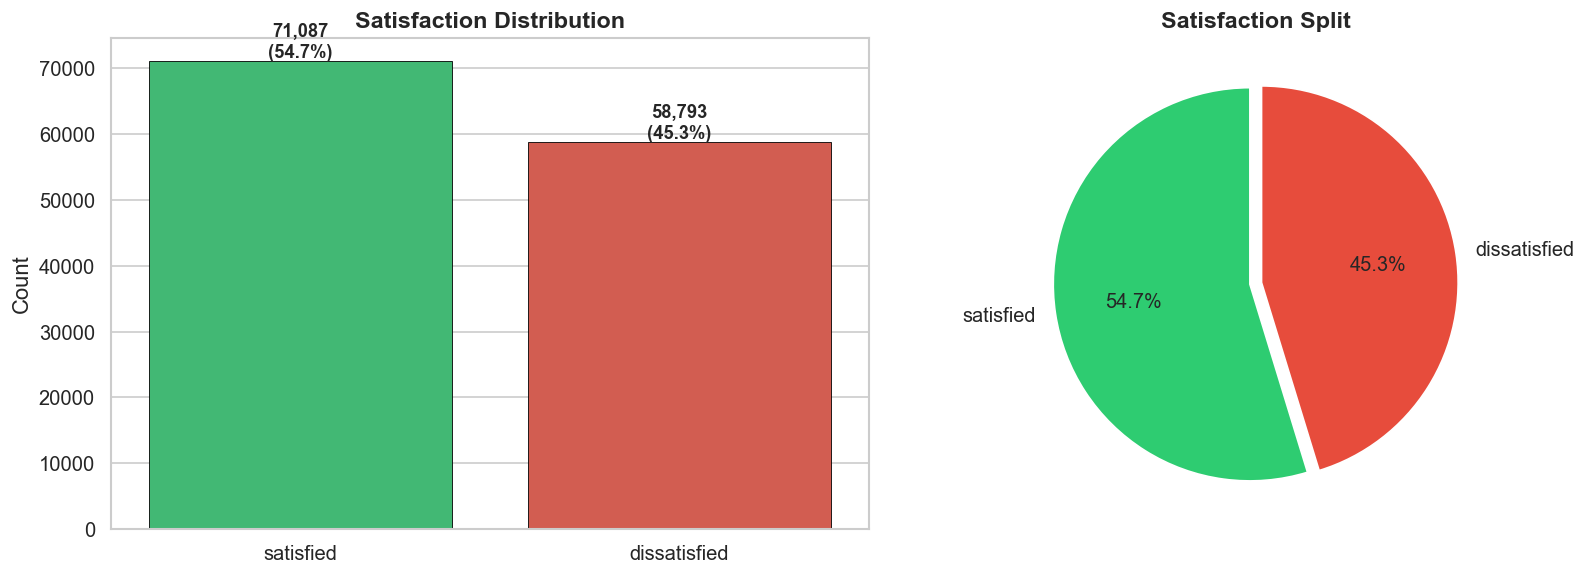

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
order = ['satisfied', 'dissatisfied']
sns.countplot(data=df, x='satisfaction', order=order, palette=SAT_PALETTE, ax=ax1,
              edgecolor='black', linewidth=0.5)
for p in ax1.patches:
    pct = p.get_height() / len(df) * 100
    ax1.annotate(f'{p.get_height():,.0f}\n({pct:.1f}%)',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Satisfaction Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Count')

ax2 = axes[1]
counts = df['satisfaction'].value_counts()
ax2.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90,
        colors=[SAT_PALETTE[k] for k in counts.index],
        explode=(0.03, 0.03), textprops={'fontsize': 12})
ax2.set_title('Satisfaction Split', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.2 Categorical Features

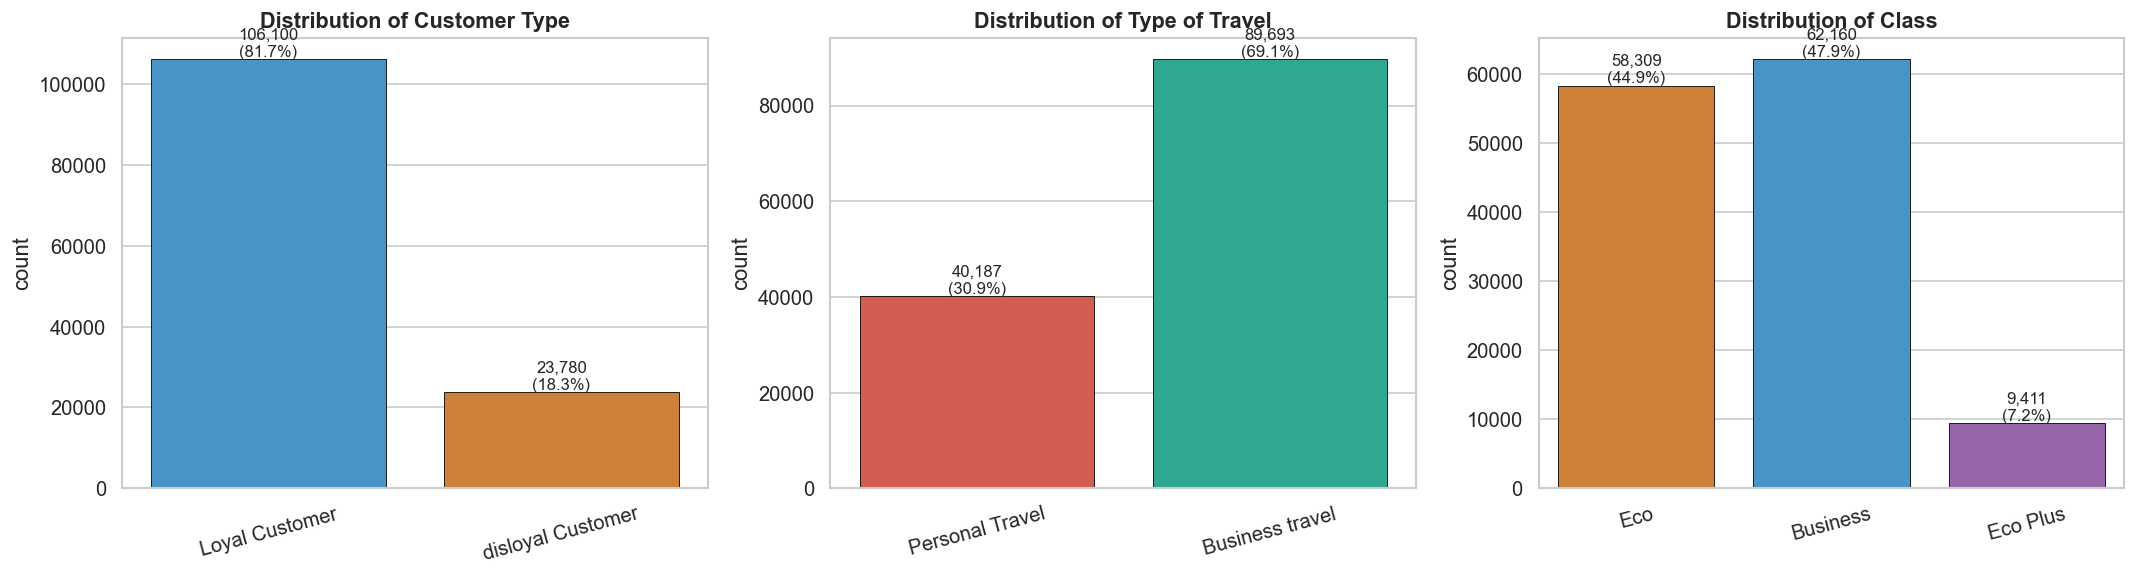

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (col, pal) in enumerate(zip(CAT_COLS, [CUST_PALETTE, TRAVEL_PALETTE, CLASS_PALETTE])):
    ax = axes[idx]
    sns.countplot(data=df, x=col, palette=pal, ax=ax, edgecolor='black', linewidth=0.5)
    for p in ax.patches:
        pct = p.get_height() / len(df) * 100
        ax.annotate(f'{p.get_height():,.0f}\n({pct:.1f}%)',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)
    ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### 4.3 Age Distribution

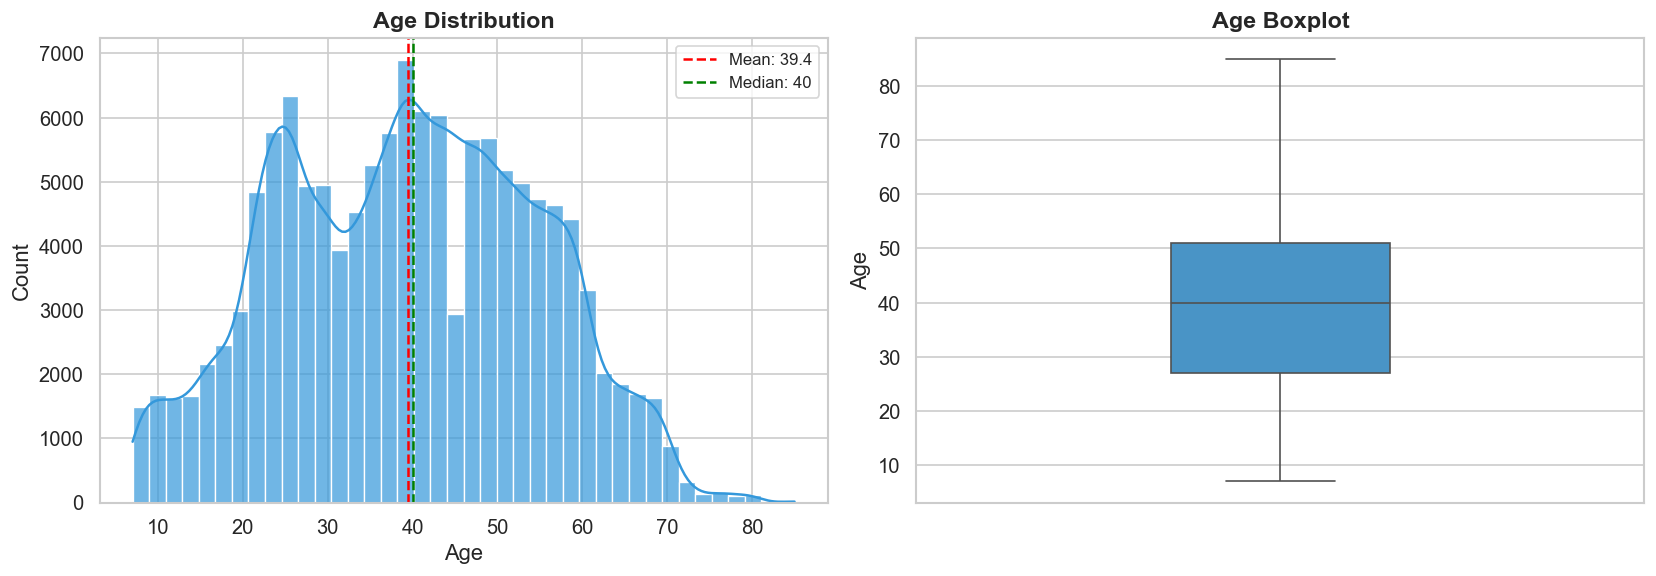

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
sns.histplot(data=df, x='Age', bins=40, kde=True, color='#3498db', edgecolor='white',
             alpha=0.7, ax=ax1)
ax1.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f"Mean: {df['Age'].mean():.1f}")
ax1.axvline(df['Age'].median(), color='green', linestyle='--', linewidth=1.5,
            label=f"Median: {df['Age'].median():.0f}")
ax1.legend(fontsize=10)
ax1.set_title('Age Distribution', fontsize=14, fontweight='bold')

ax2 = axes[1]
sns.boxplot(data=df, y='Age', color='#3498db', width=0.3, ax=ax2)
ax2.set_title('Age Boxplot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.4 Flight Distance Distribution

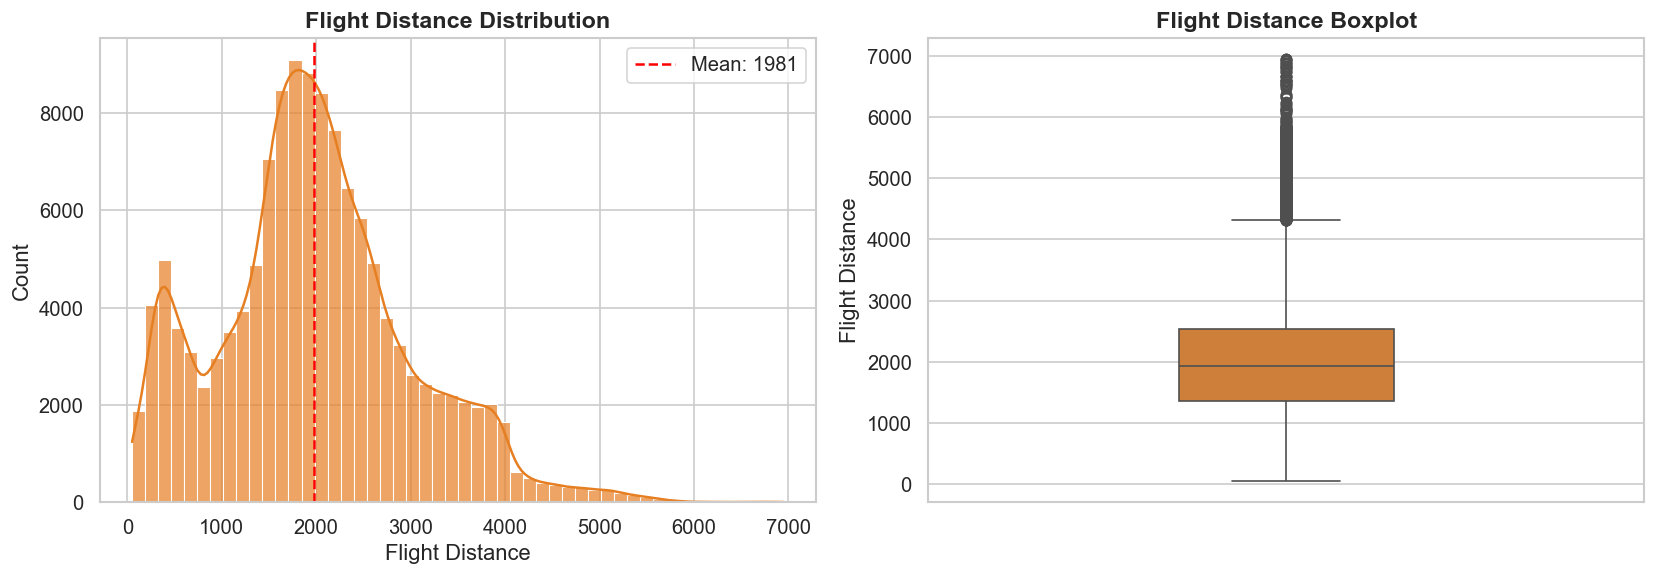

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Flight Distance', bins=50, kde=True, color='#e67e22',
             edgecolor='white', alpha=0.7, ax=axes[0])
axes[0].axvline(df['Flight Distance'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['Flight Distance'].mean():.0f}")
axes[0].legend()
axes[0].set_title('Flight Distance Distribution', fontsize=14, fontweight='bold')

sns.boxplot(data=df, y='Flight Distance', color='#e67e22', width=0.3, ax=axes[1])
axes[1].set_title('Flight Distance Boxplot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.5 Delay Distributions

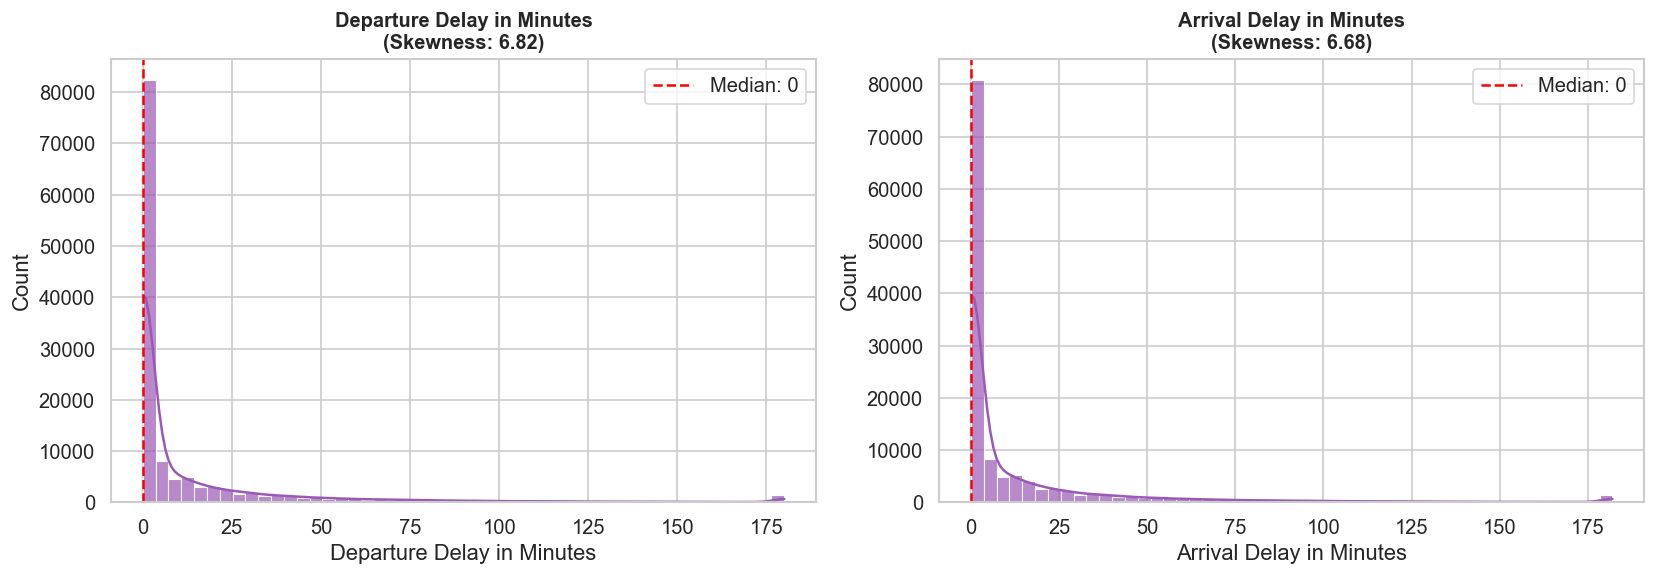


Departure Delay in Minutes:
  Mean: 14.7, Median: 0.0, Max: 1592, Skew: 6.82
  Zero-delay pct: 56.5%

Arrival Delay in Minutes:
  Mean: 15.0, Median: 0.0, Max: 1584, Skew: 6.68
  Zero-delay pct: 56.3%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, col in enumerate(DELAY_COLS):
    ax = axes[idx]
    data_clipped = df[col].clip(upper=df[col].quantile(0.99))
    sns.histplot(data_clipped, bins=50, kde=True, color='#9b59b6', edgecolor='white',
                 alpha=0.7, ax=ax)
    skew = df[col].skew()
    ax.set_title(f'{col}\n(Skewness: {skew:.2f})', fontsize=12, fontweight='bold')
    ax.axvline(df[col].median(), color='red', linestyle='--',
               label=f'Median: {df[col].median():.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

for col in DELAY_COLS:
    print(f'\n{col}:')
    print(f'  Mean: {df[col].mean():.1f}, Median: {df[col].median():.1f}, '
          f'Max: {df[col].max():.0f}, Skew: {df[col].skew():.2f}')
    print(f'  Zero-delay pct: {(df[col] == 0).sum() / len(df) * 100:.1f}%')

### 4.6 Service Ratings Distributions

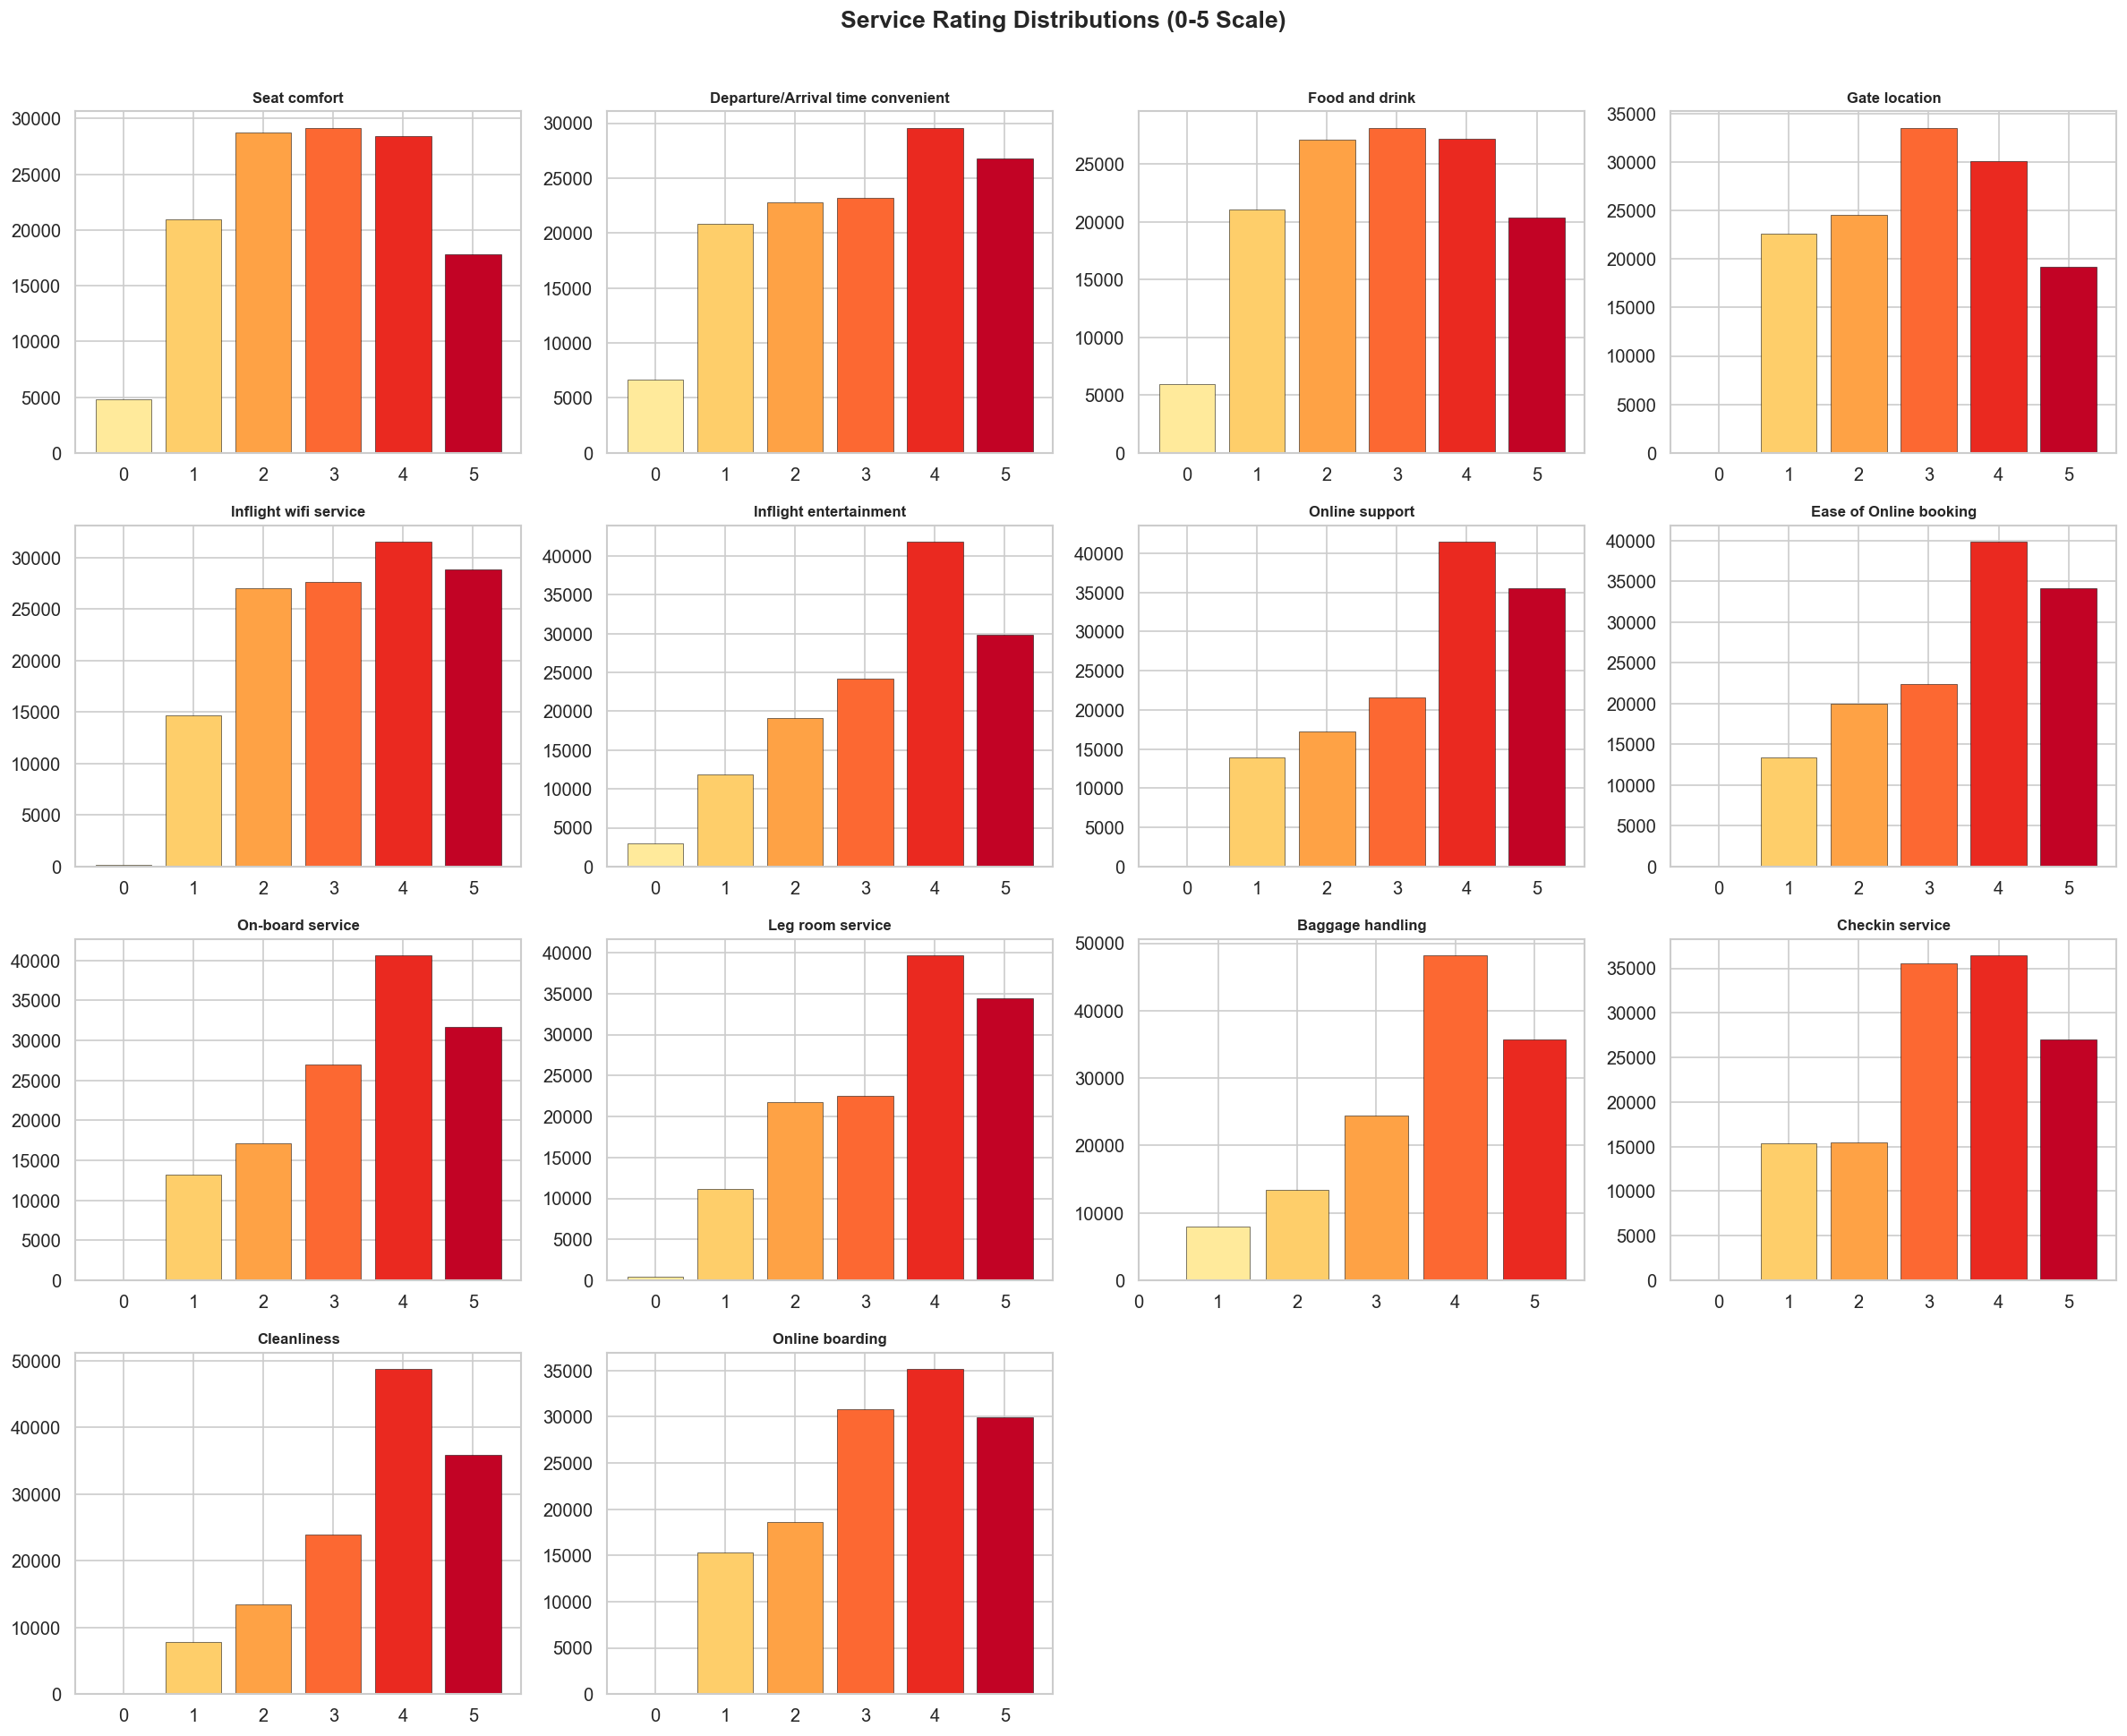

In [14]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes_flat = axes.flatten()

for idx, col in enumerate(SERVICE_COLS):
    ax = axes_flat[idx]
    val_counts = df[col].value_counts().sort_index()
    colors = sns.color_palette('YlOrRd', n_colors=6)
    ax.bar(val_counts.index, val_counts.values, color=colors, edgecolor='black', linewidth=0.3)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks(range(6))

for idx in range(len(SERVICE_COLS), len(axes_flat)):
    axes_flat[idx].set_visible(False)

fig.suptitle('Service Rating Distributions (0-5 Scale)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

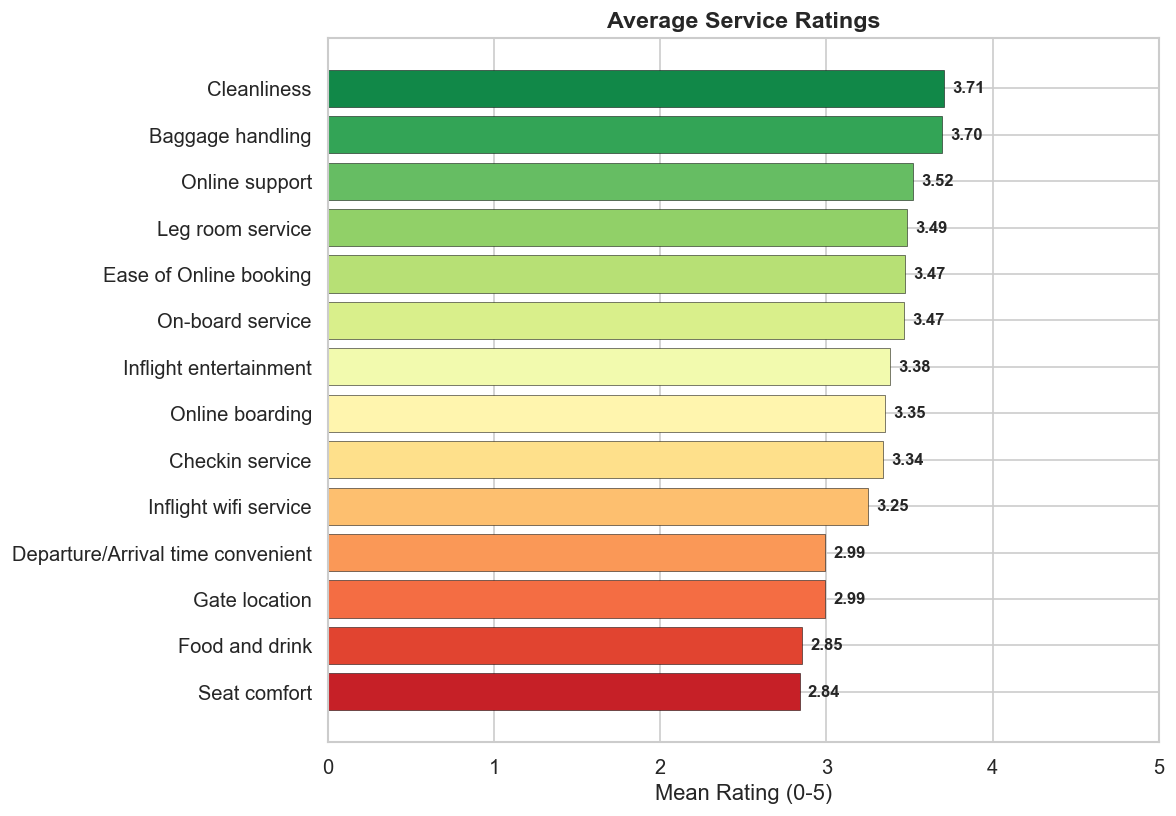

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))
avg_ratings = df[SERVICE_COLS].mean().sort_values(ascending=True)
colors = sns.color_palette('RdYlGn', n_colors=len(avg_ratings))
bars = ax.barh(avg_ratings.index, avg_ratings.values, color=colors, edgecolor='black', linewidth=0.3)
for bar, val in zip(bars, avg_ratings.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
            va='center', fontsize=10, fontweight='bold')
ax.set_xlim(0, 5)
ax.set_title('Average Service Ratings', fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Rating (0-5)')
plt.tight_layout()
plt.show()

## 5. Bivariate Analysis
Explore relationships between `satisfaction` and other features.

### 5.1 Satisfaction vs Categorical Variables

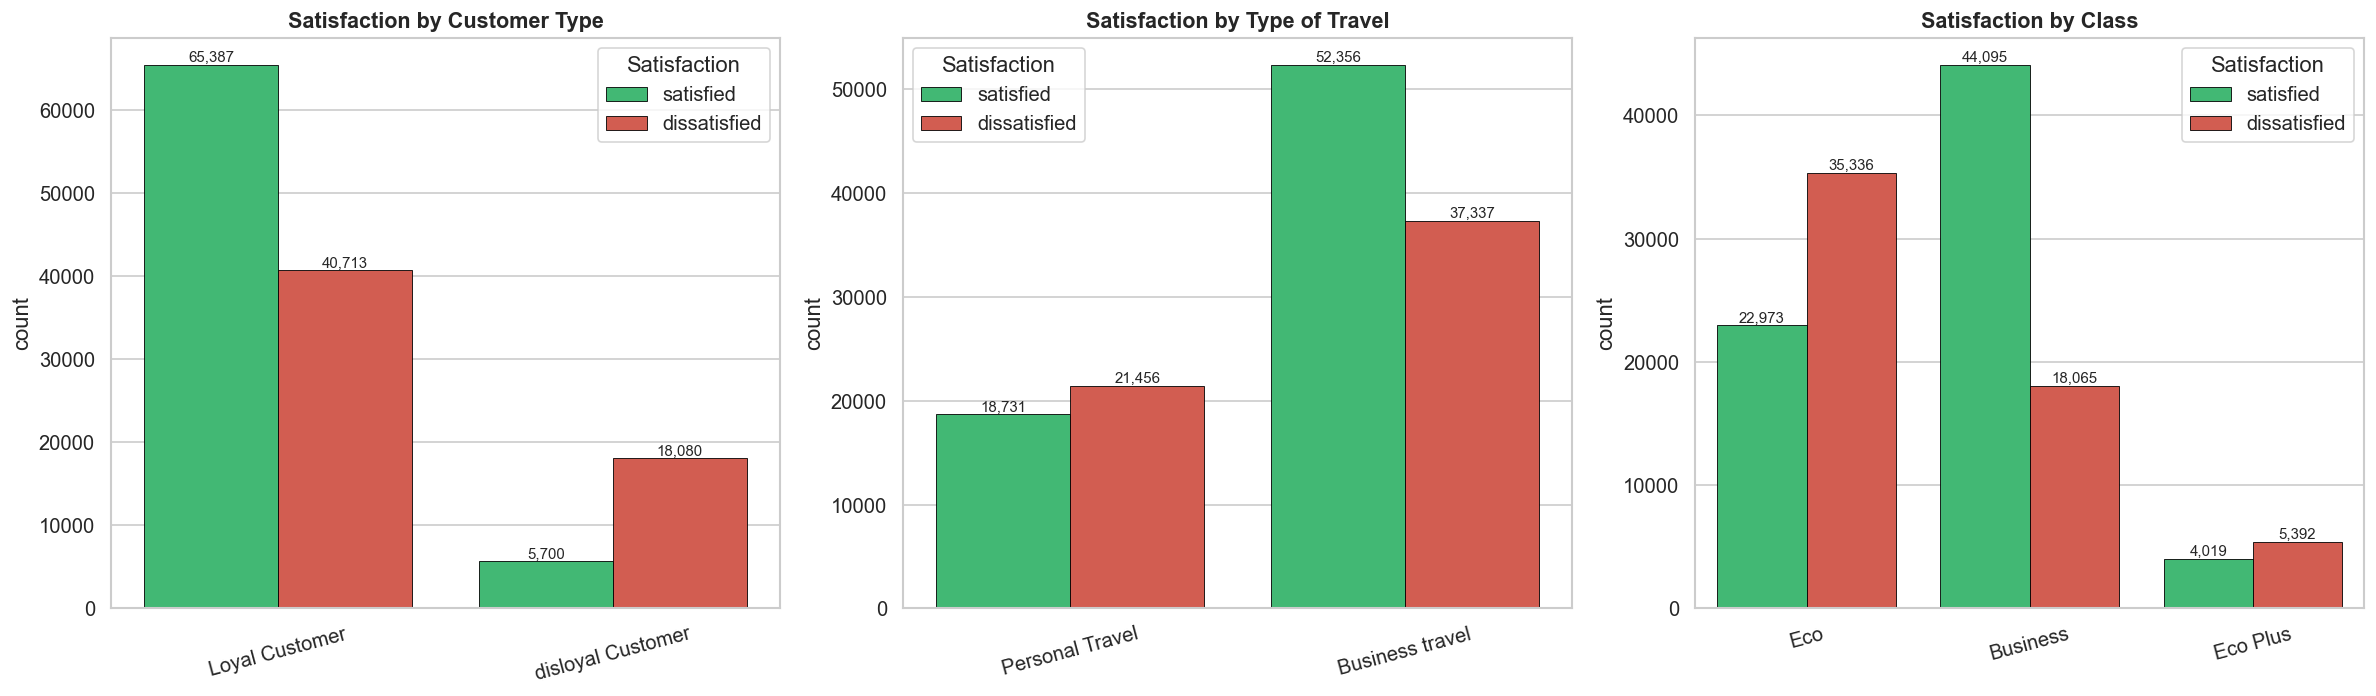

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, col in enumerate(CAT_COLS):
    ax = axes[idx]
    sns.countplot(data=df, x=col, hue='satisfaction', palette=SAT_PALETTE,
                  ax=ax, edgecolor='black', linewidth=0.5)
    ax.set_title(f'Satisfaction by {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Satisfaction')
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():,.0f}',
                        (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

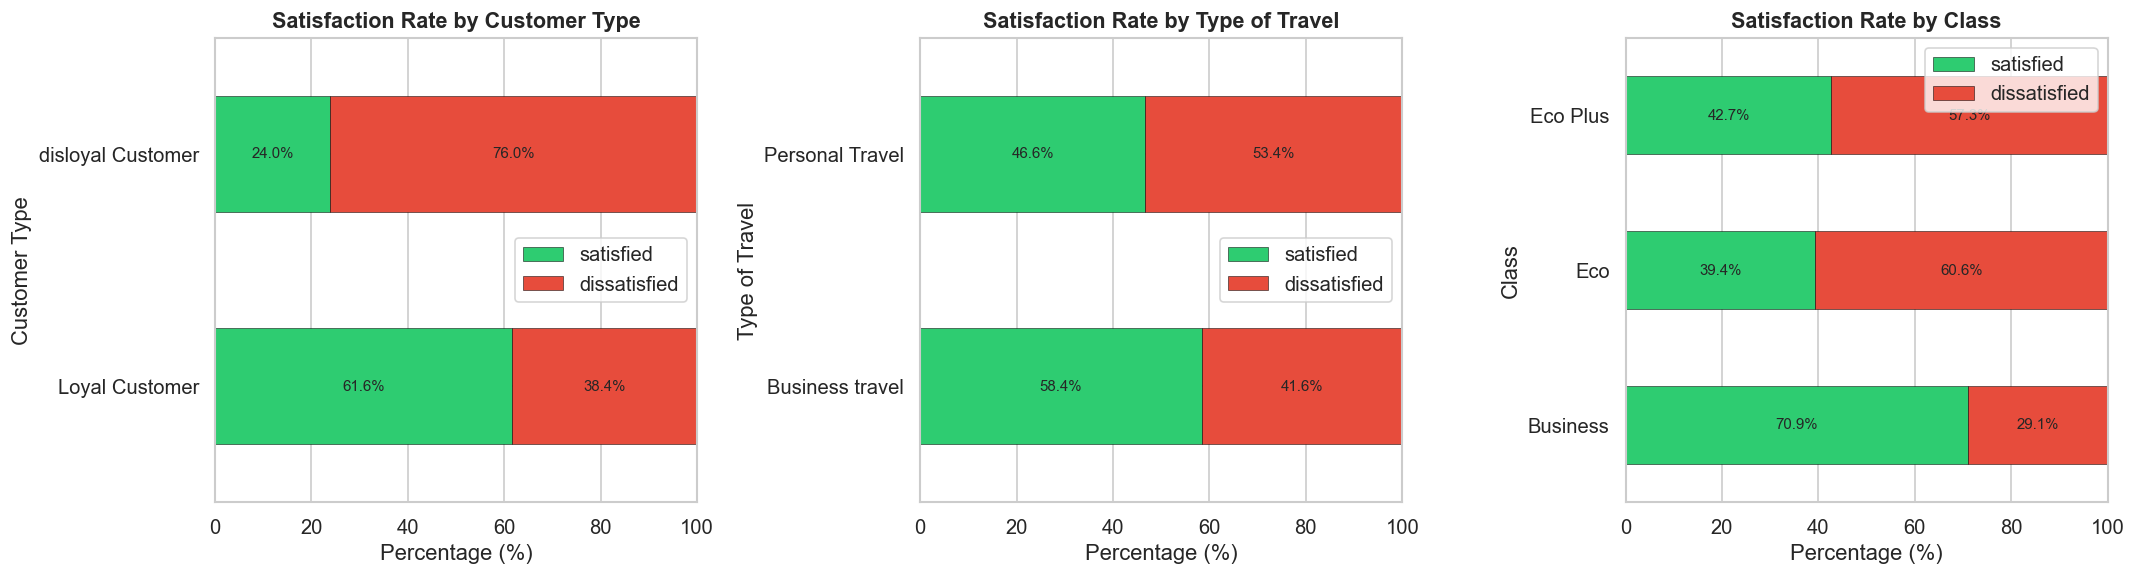

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(CAT_COLS):
    ax = axes[idx]
    ct = pd.crosstab(df[col], df['satisfaction'], normalize='index') * 100
    ct[['satisfied', 'dissatisfied']].plot(kind='barh', stacked=True, ax=ax,
        color=[SAT_PALETTE['satisfied'], SAT_PALETTE['dissatisfied']],
        edgecolor='black', linewidth=0.3)
    ax.set_title(f'Satisfaction Rate by {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Percentage (%)')
    ax.set_xlim(0, 100)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=9)
    ax.legend(title='')

plt.tight_layout()
plt.show()

### 5.2 Satisfaction vs Age

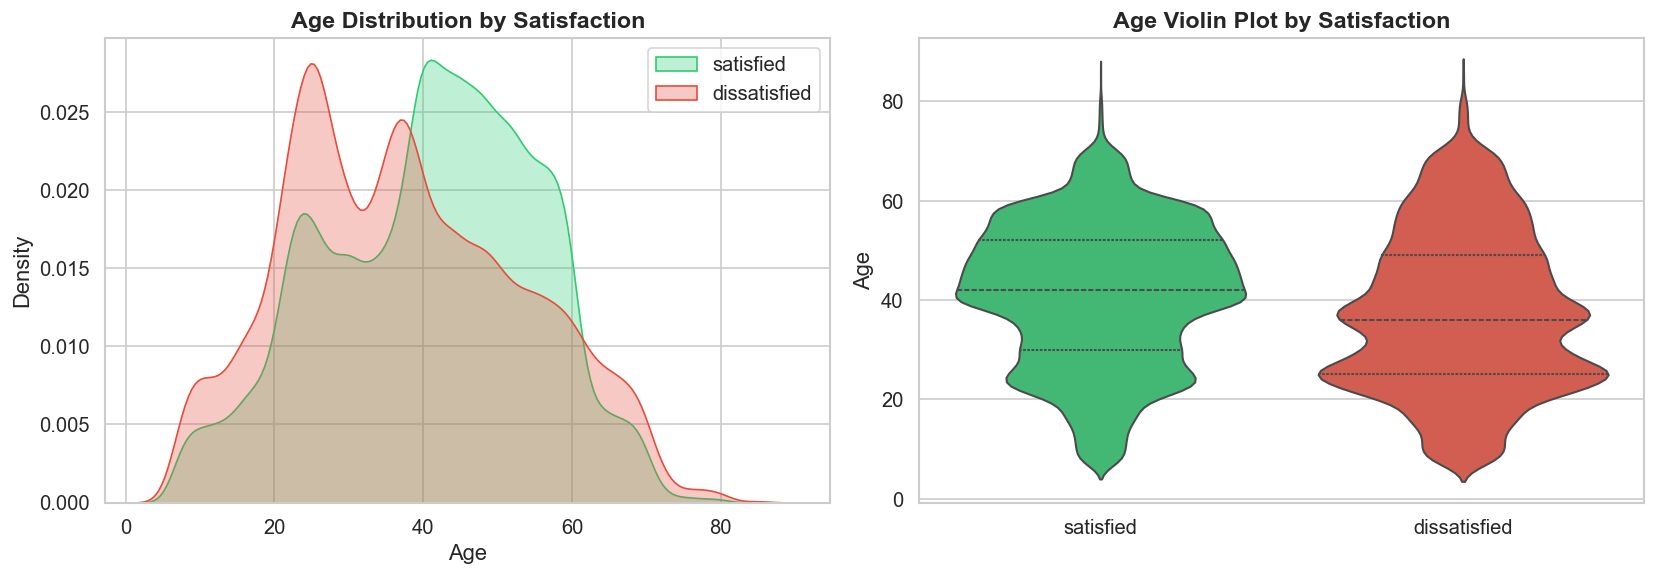

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
for label, color in SAT_PALETTE.items():
    subset = df[df['satisfaction'] == label]['Age']
    sns.kdeplot(subset, color=color, label=label, fill=True, alpha=0.3, ax=ax1)
ax1.set_title('Age Distribution by Satisfaction', fontsize=14, fontweight='bold')
ax1.legend()

ax2 = axes[1]
sns.violinplot(data=df, x='satisfaction', y='Age', palette=SAT_PALETTE,
               order=['satisfied', 'dissatisfied'], ax=ax2, inner='quartile')
ax2.set_title('Age Violin Plot by Satisfaction', fontsize=14, fontweight='bold')
ax2.set_xlabel('')

plt.tight_layout()
plt.show()

### 5.3 Satisfaction vs Flight Distance

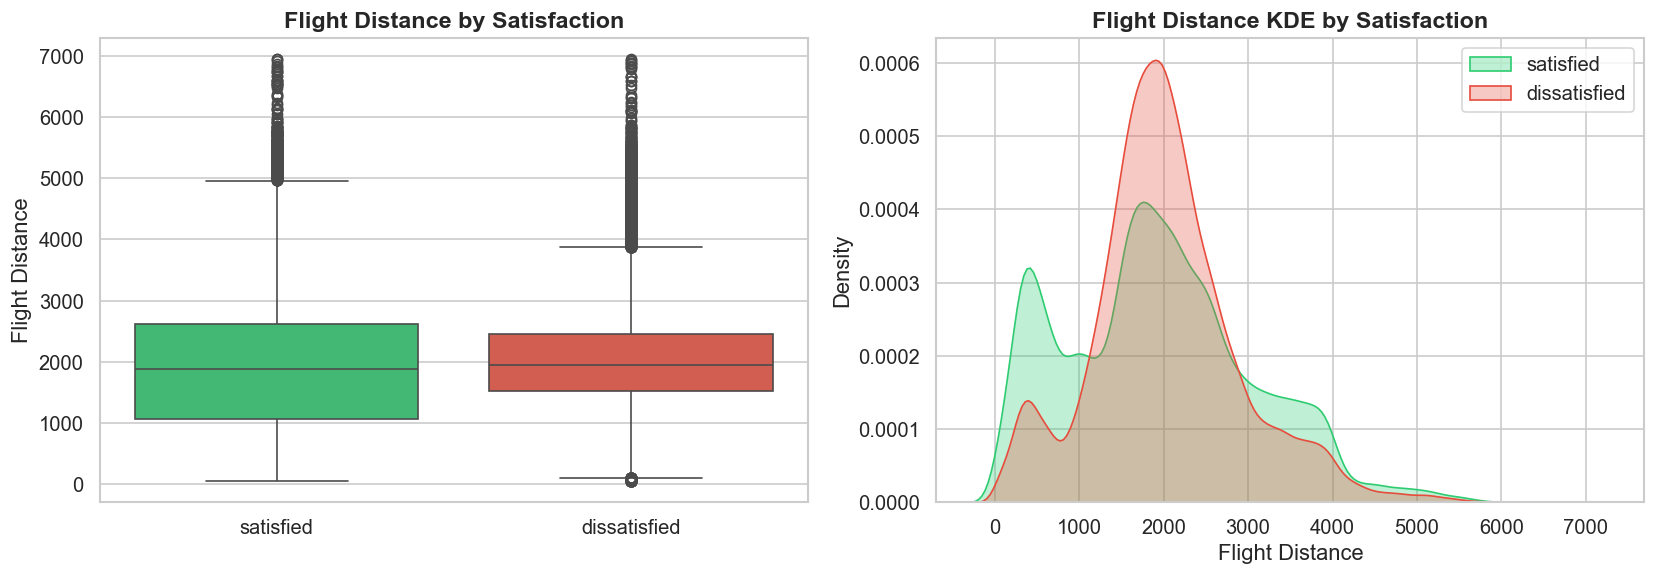

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='satisfaction', y='Flight Distance', palette=SAT_PALETTE,
            order=['satisfied', 'dissatisfied'], ax=axes[0])
axes[0].set_title('Flight Distance by Satisfaction', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')

for label, color in SAT_PALETTE.items():
    subset = df[df['satisfaction'] == label]['Flight Distance']
    sns.kdeplot(subset, color=color, label=label, fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title('Flight Distance KDE by Satisfaction', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.4 Class vs Satisfaction — Heatmap

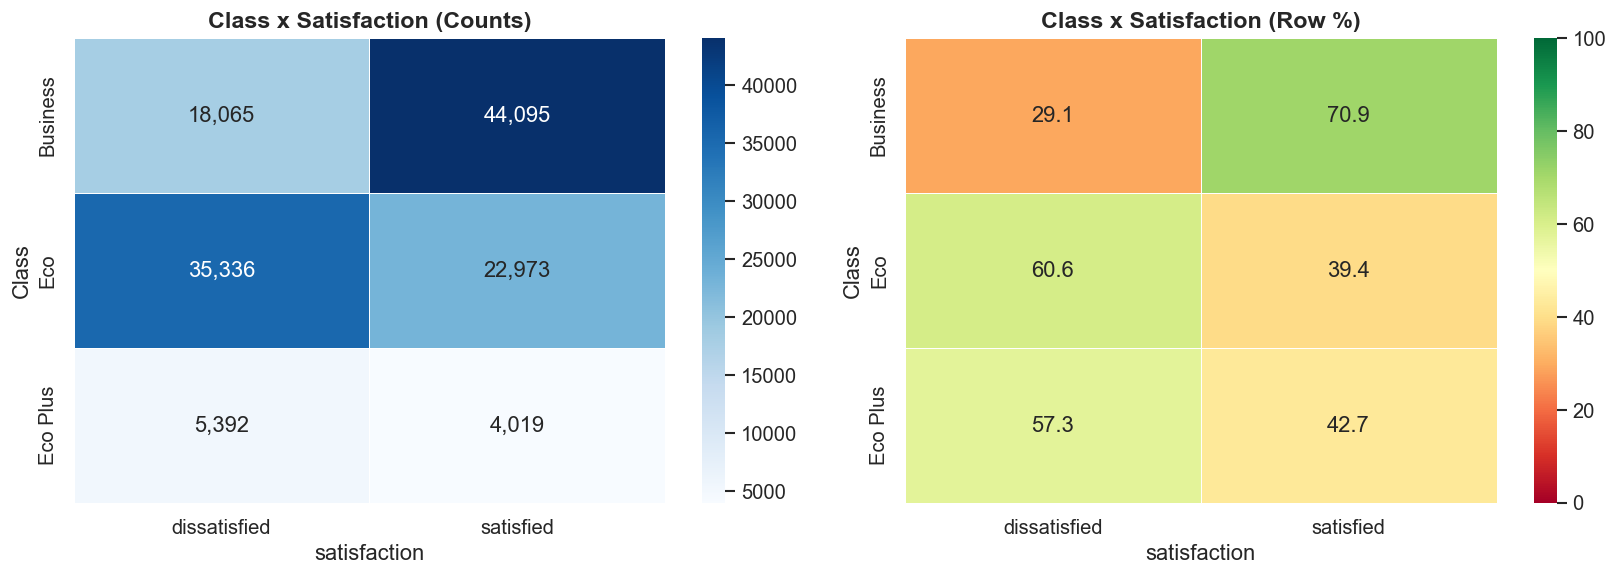

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_raw = pd.crosstab(df['Class'], df['satisfaction'])
sns.heatmap(ct_raw, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            linewidths=0.5, linecolor='white')
axes[0].set_title('Class x Satisfaction (Counts)', fontsize=14, fontweight='bold')

ct_norm = pd.crosstab(df['Class'], df['satisfaction'], normalize='index') * 100
sns.heatmap(ct_norm, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
            linewidths=0.5, linecolor='white', vmin=0, vmax=100)
axes[1].set_title('Class x Satisfaction (Row %)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 5.5 Service Ratings by Satisfaction

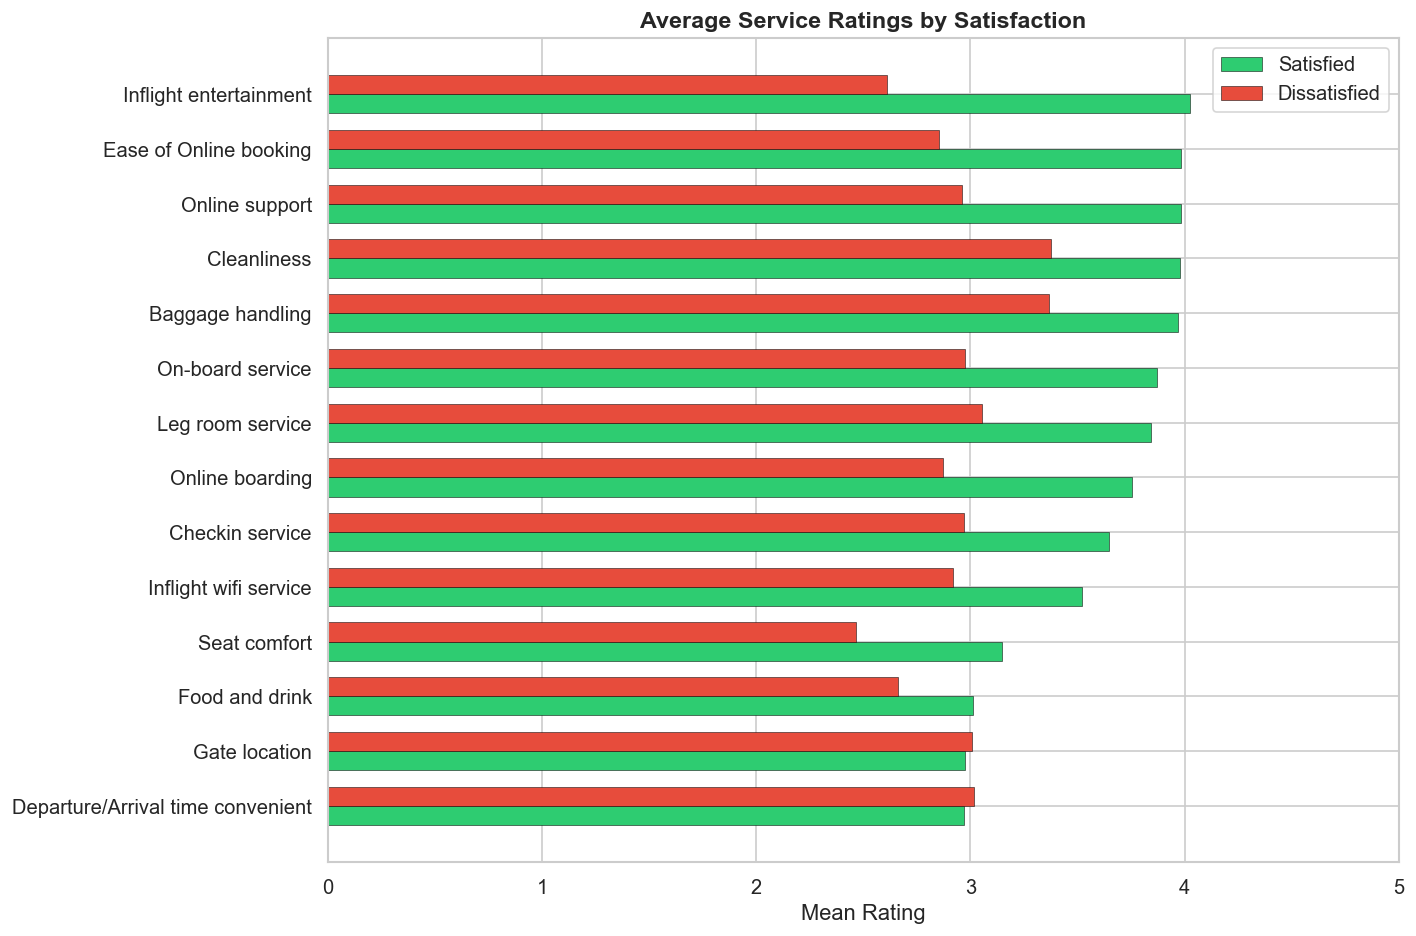

In [21]:
fig, ax = plt.subplots(figsize=(12, 8))

means = df.groupby('satisfaction')[SERVICE_COLS].mean().T
means = means.sort_values('satisfied', ascending=True)

y = np.arange(len(means))
height = 0.35

bars1 = ax.barh(y - height/2, means['satisfied'], height, label='Satisfied',
                color=SAT_PALETTE['satisfied'], edgecolor='black', linewidth=0.3)
bars2 = ax.barh(y + height/2, means['dissatisfied'], height, label='Dissatisfied',
                color=SAT_PALETTE['dissatisfied'], edgecolor='black', linewidth=0.3)

ax.set_yticks(y)
ax.set_yticklabels(means.index)
ax.set_xlim(0, 5)
ax.set_xlabel('Mean Rating')
ax.set_title('Average Service Ratings by Satisfaction', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

### 5.6 Delays vs Satisfaction

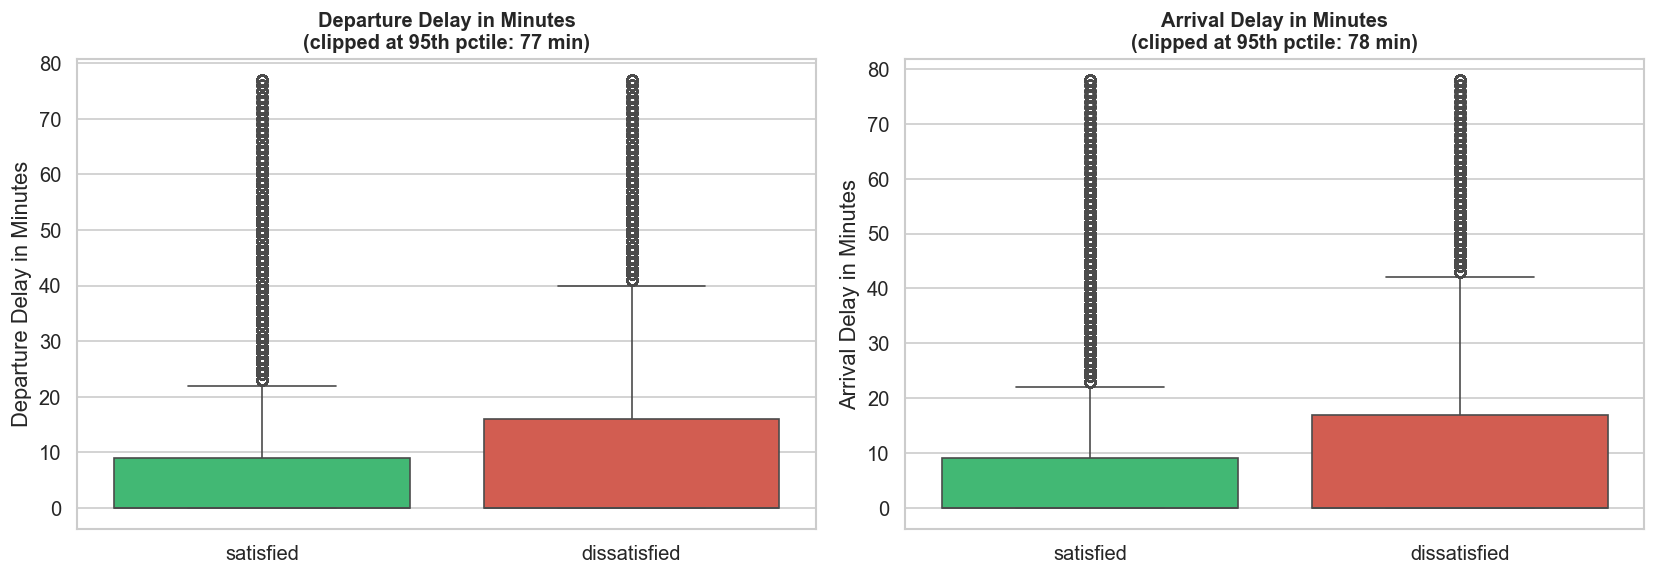

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, col in enumerate(DELAY_COLS):
    ax = axes[idx]
    temp = df[[col, 'satisfaction']].copy()
    clip_val = temp[col].quantile(0.95)
    temp[col] = temp[col].clip(upper=clip_val)
    sns.boxplot(data=temp, x='satisfaction', y=col, palette=SAT_PALETTE,
                order=['satisfied', 'dissatisfied'], ax=ax)
    ax.set_title(f'{col}\n(clipped at 95th pctile: {clip_val:.0f} min)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

## 6. Multivariate Analysis
Examine interactions among multiple variables simultaneously.

### 6.1 Correlation Heatmap

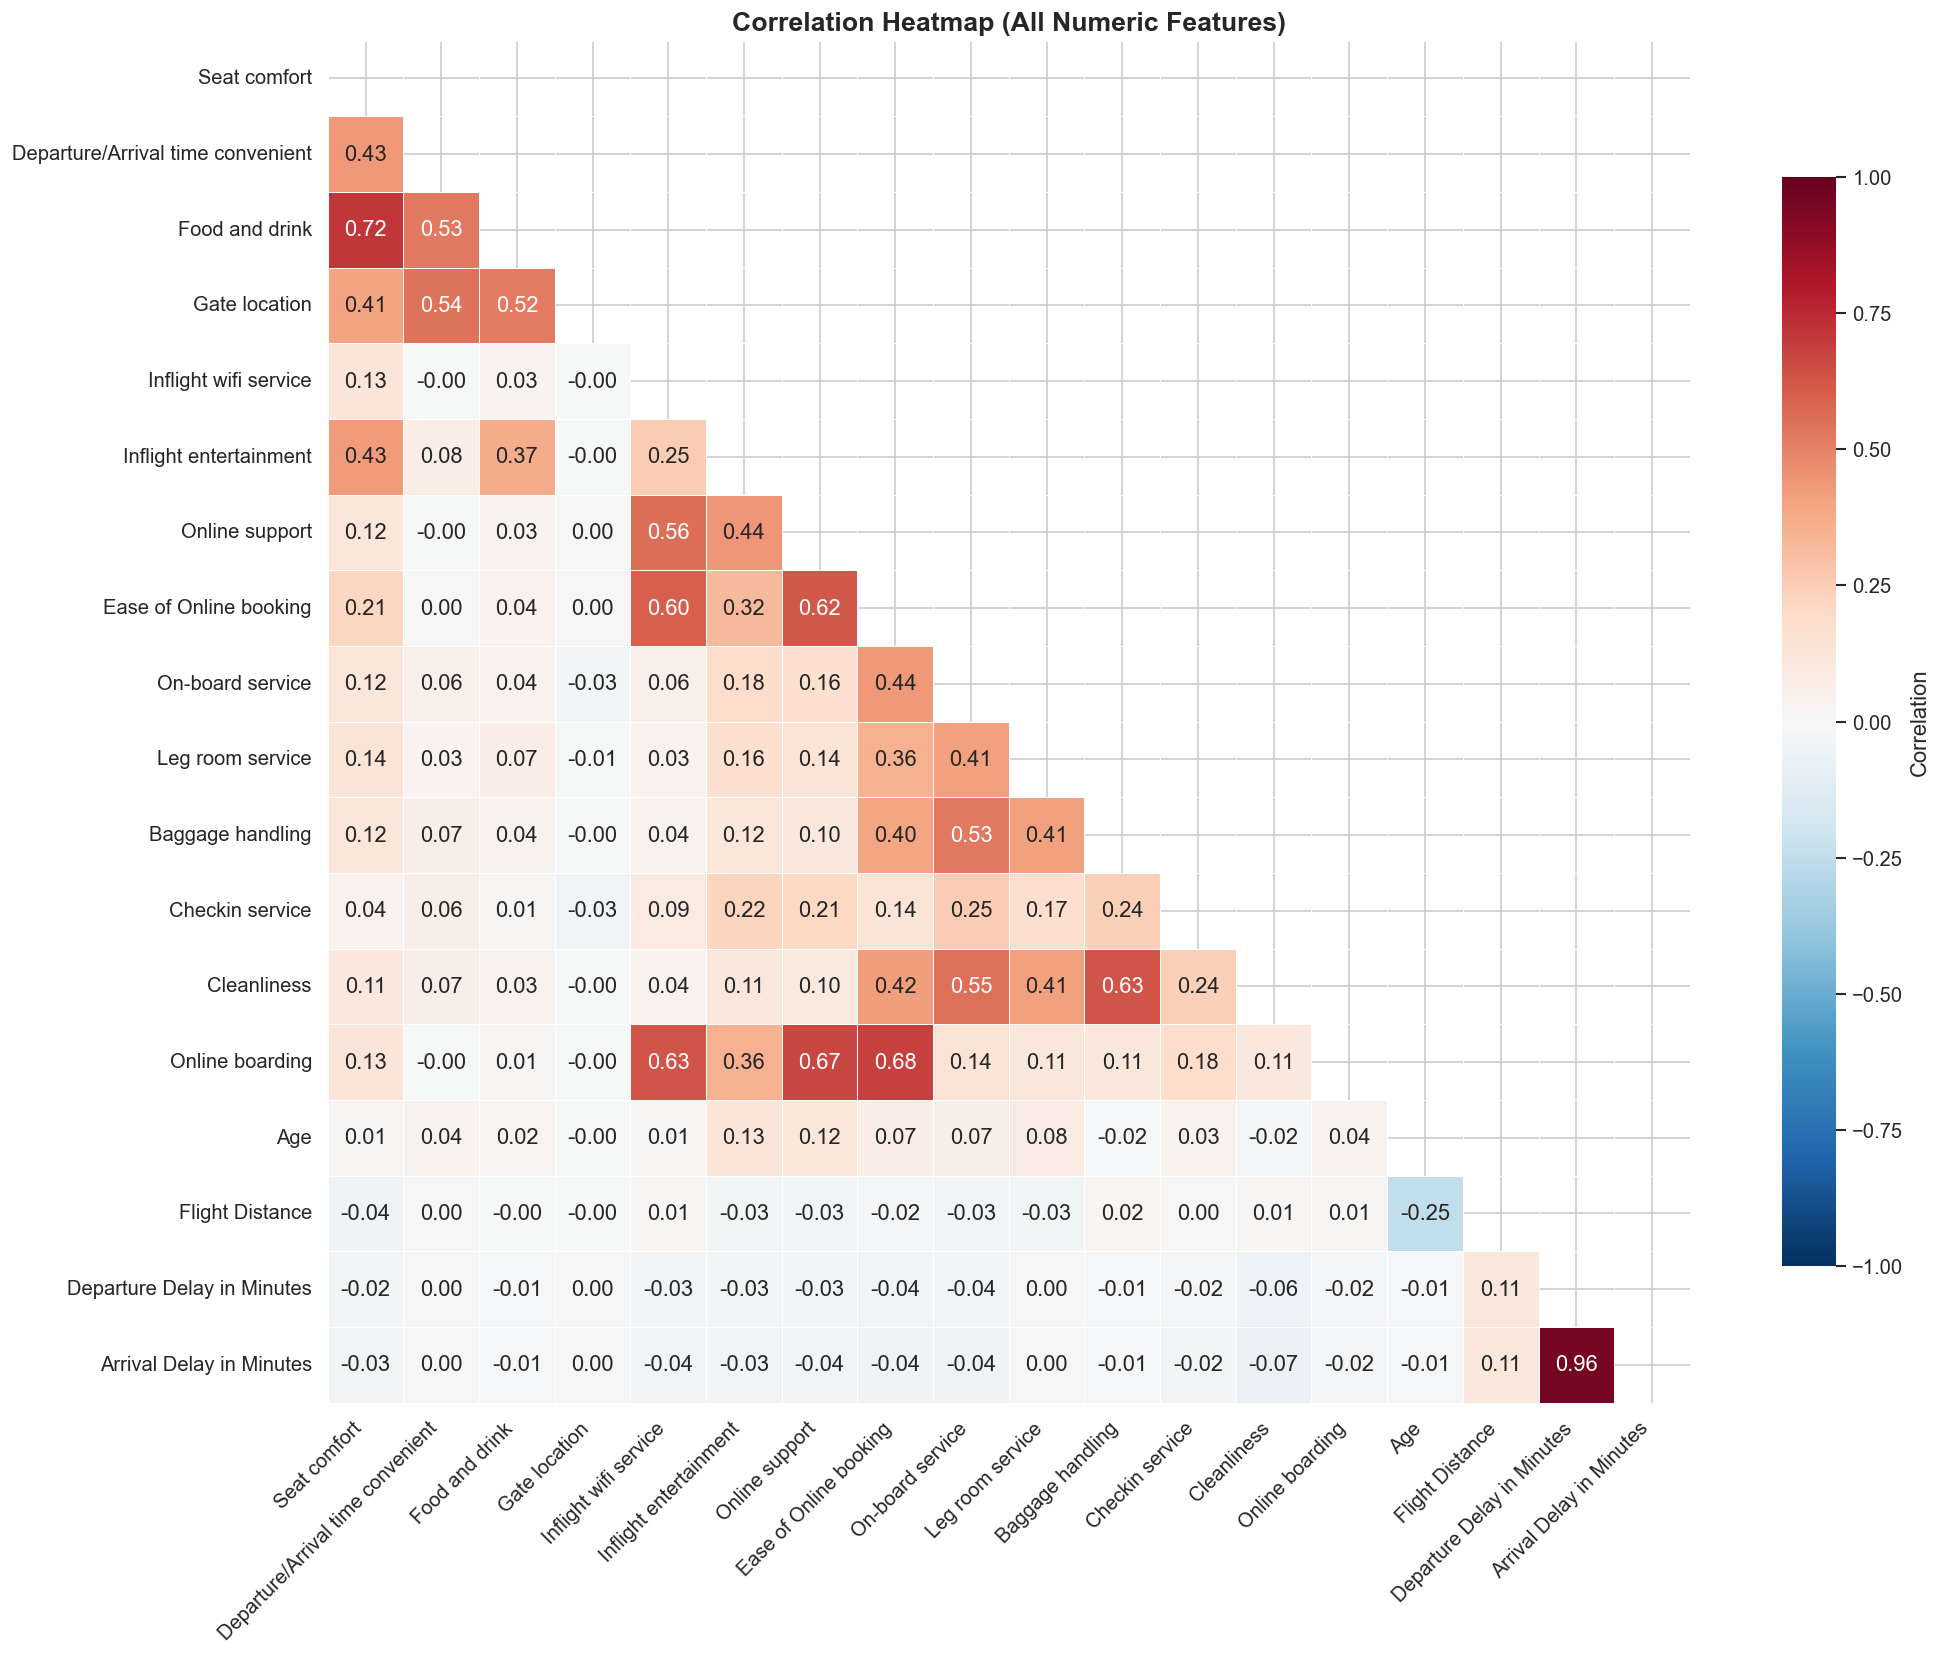

In [23]:
numeric_cols = SERVICE_COLS + CONT_COLS
corr = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax)
ax.set_title('Correlation Heatmap (All Numeric Features)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.2 Pairplot — Key Continuous Variables

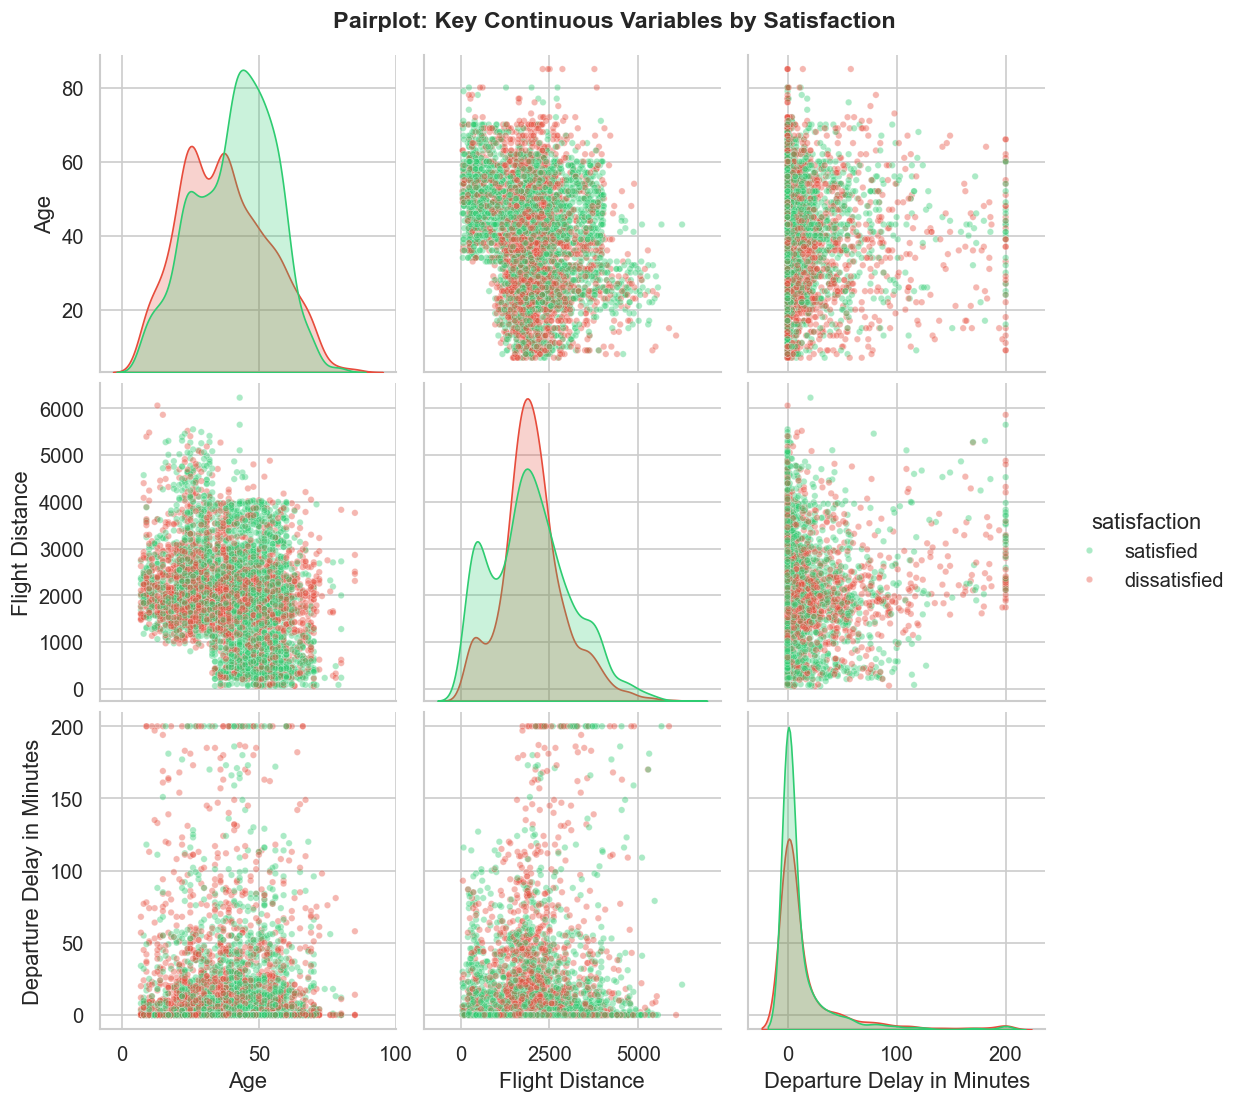

In [24]:
sample = df[['Age', 'Flight Distance', 'Departure Delay in Minutes', 'satisfaction']].copy()
sample['Departure Delay in Minutes'] = sample['Departure Delay in Minutes'].clip(upper=200)
sample_df = sample.sample(n=5000, random_state=42)

g = sns.pairplot(sample_df, hue='satisfaction', palette=SAT_PALETTE,
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15},
                 height=3)
g.figure.suptitle('Pairplot: Key Continuous Variables by Satisfaction',
                  fontsize=14, fontweight='bold', y=1.02)
plt.show()

### 6.3 Radar Chart — Service Ratings by Satisfaction

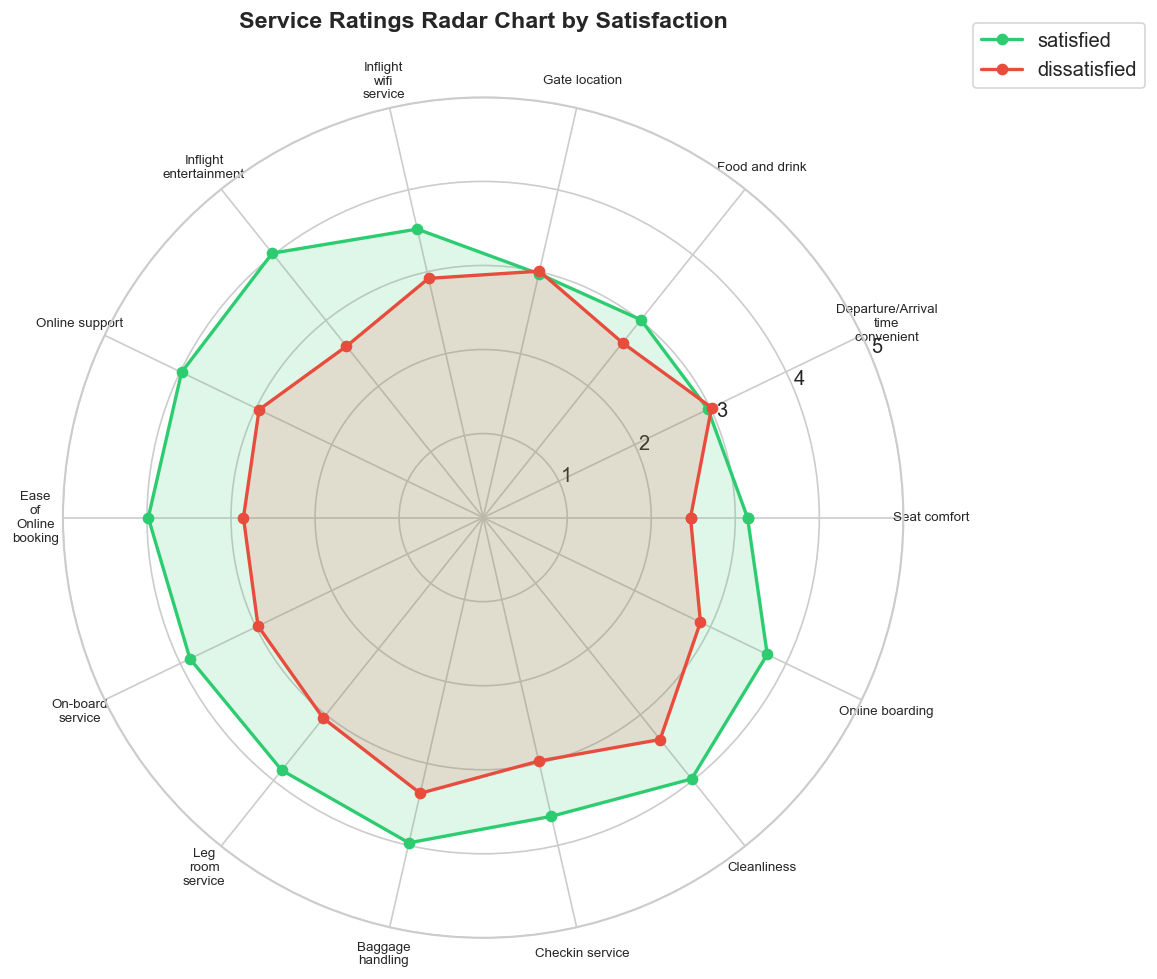

In [25]:
means = df.groupby('satisfaction')[SERVICE_COLS].mean()
categories = SERVICE_COLS
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for label, color in SAT_PALETTE.items():
    values = means.loc[label].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=label, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.replace(' ', '\n') if len(c) > 15 else c for c in categories],
                    fontsize=8)
ax.set_ylim(0, 5)
ax.set_title('Service Ratings Radar Chart by Satisfaction',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

### 6.4 Class x Travel Type x Satisfaction

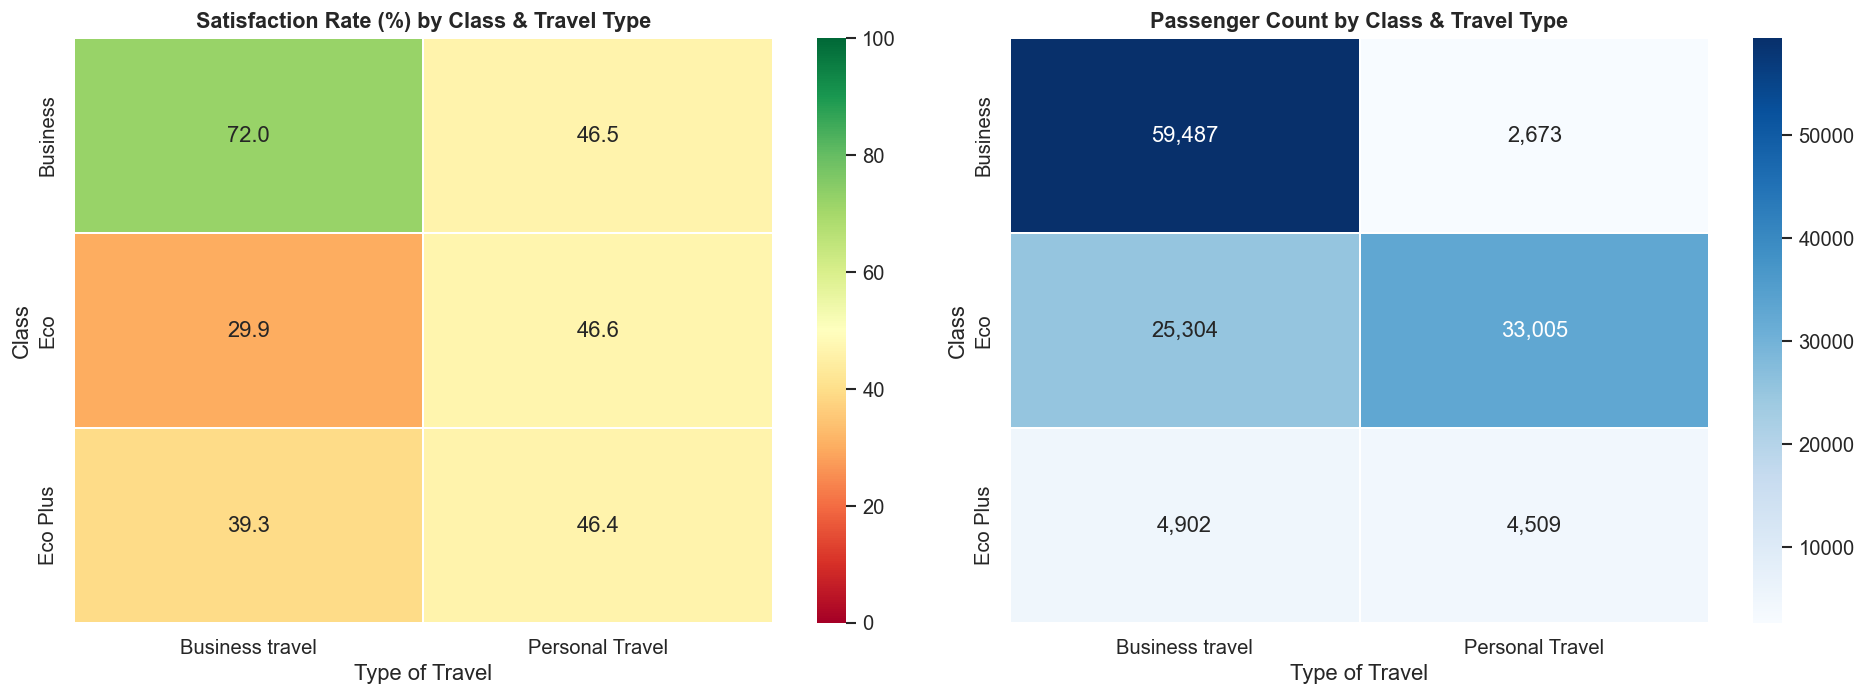

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ct = pd.crosstab([df['Class'], df['Type of Travel']], df['satisfaction'],
                 normalize='index')['satisfied'] * 100
ct_pivot = ct.unstack(level=1)

sns.heatmap(ct_pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0],
            linewidths=1, linecolor='white', vmin=0, vmax=100)
axes[0].set_title('Satisfaction Rate (%) by Class & Travel Type',
                  fontsize=13, fontweight='bold')

ct_count = pd.crosstab(df['Class'], df['Type of Travel'])
sns.heatmap(ct_count, annot=True, fmt=',d', cmap='Blues', ax=axes[1],
            linewidths=1, linecolor='white')
axes[1].set_title('Passenger Count by Class & Travel Type',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Deep Dive: Service Ratings
Which services drive satisfaction the most? How do ratings vary by class?

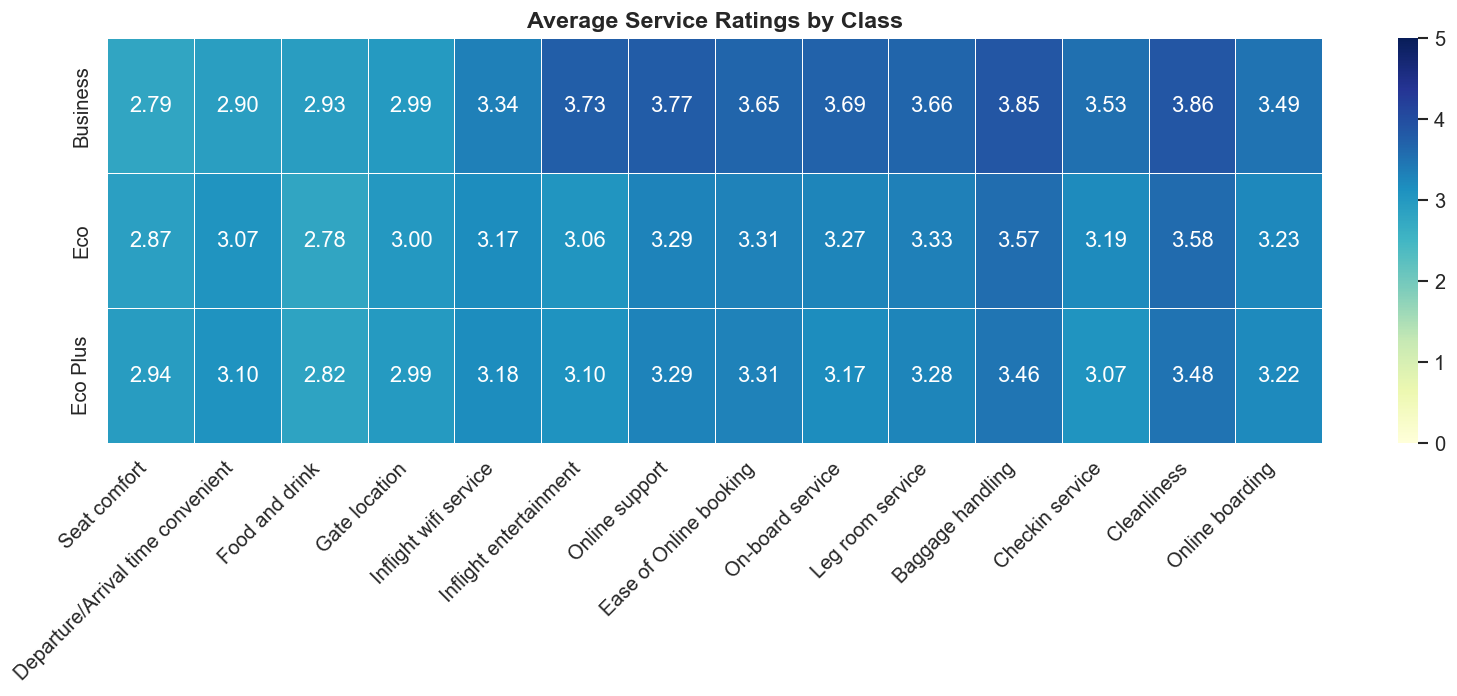

In [27]:
fig, ax = plt.subplots(figsize=(14, 6))

class_service_means = df.groupby('Class')[SERVICE_COLS].mean()
sns.heatmap(class_service_means, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, linecolor='white', ax=ax, vmin=0, vmax=5)
ax.set_title('Average Service Ratings by Class', fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

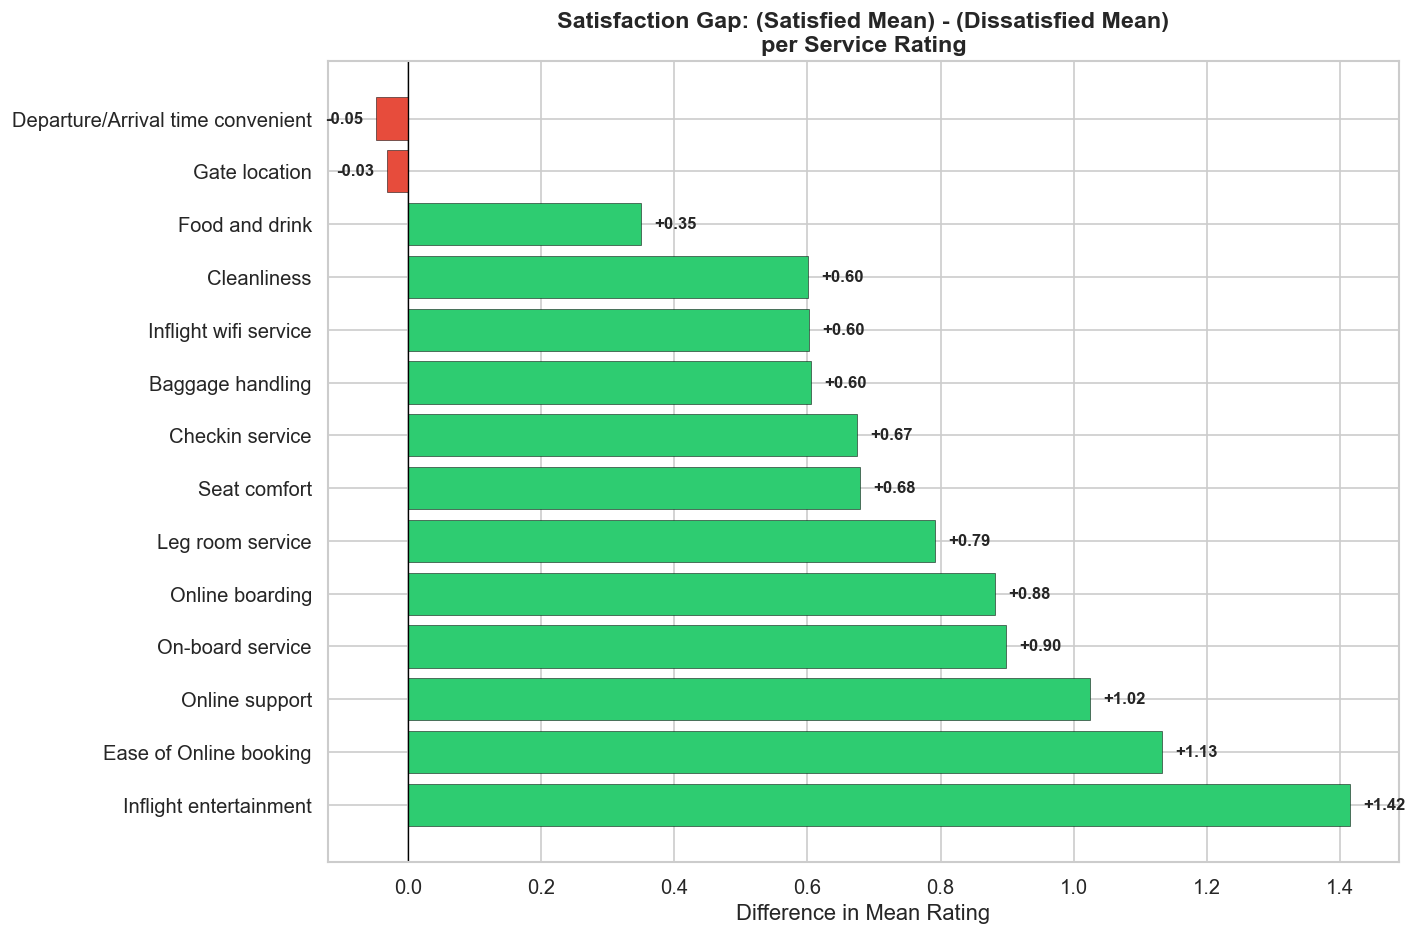

In [28]:
fig, ax = plt.subplots(figsize=(12, 8))

sat_means = df.groupby('satisfaction')[SERVICE_COLS].mean()
diff = (sat_means.loc['satisfied'] - sat_means.loc['dissatisfied']).sort_values(ascending=False)

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in diff.values]
bars = ax.barh(diff.index, diff.values, color=colors, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Satisfaction Gap: (Satisfied Mean) - (Dissatisfied Mean)\nper Service Rating',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Difference in Mean Rating')

for bar, val in zip(bars, diff.values):
    ax.text(val + (0.02 if val >= 0 else -0.02), bar.get_y() + bar.get_height()/2,
            f'{val:+.2f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

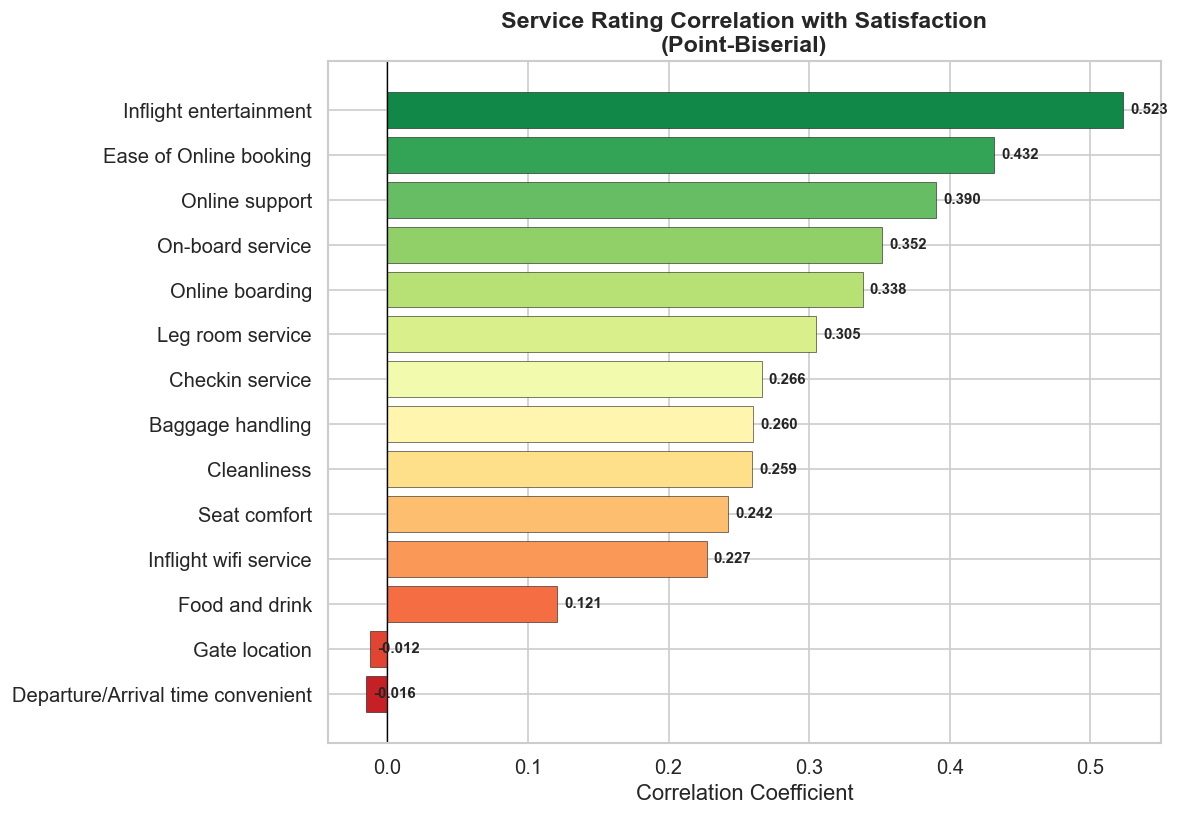

In [29]:
df['satisfaction_encoded'] = (df['satisfaction'] == 'satisfied').astype(int)

correlations = {}
for col in SERVICE_COLS:
    corr_val, pval = stats.pointbiserialr(df['satisfaction_encoded'], df[col])
    correlations[col] = {'correlation': corr_val, 'p_value': pval}

corr_df = pd.DataFrame(correlations).T.sort_values('correlation', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette('RdYlGn', n_colors=len(corr_df))
bars = ax.barh(corr_df.index[::-1], corr_df['correlation'][::-1], color=colors,
               edgecolor='black', linewidth=0.3)
ax.set_title('Service Rating Correlation with Satisfaction\n(Point-Biserial)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, corr_df['correlation'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

df.drop('satisfaction_encoded', axis=1, inplace=True)

## 8. Delay Analysis
Understand the distribution, outliers, and relationship between delays and satisfaction.

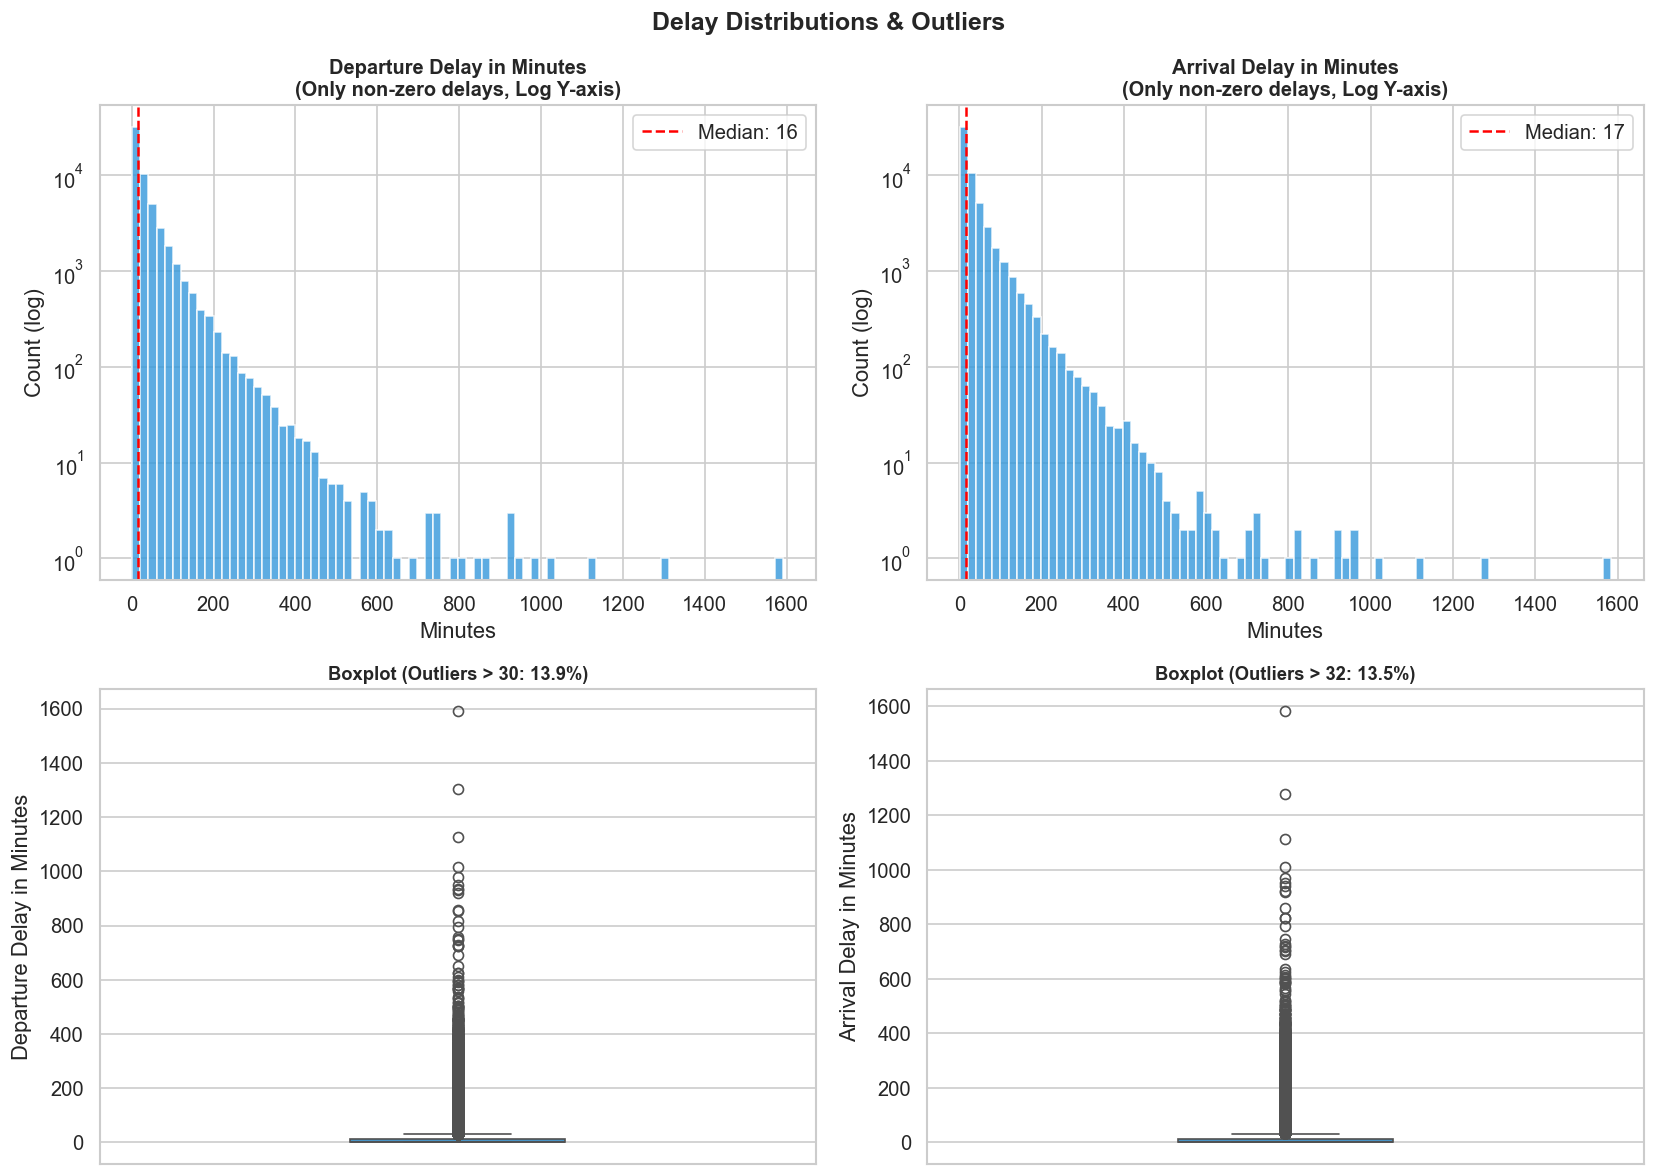

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, col in enumerate(DELAY_COLS):
    ax1 = axes[0][idx]
    delay_data = df[col][df[col] > 0]
    ax1.hist(delay_data, bins=80, color='#3498db', edgecolor='white', alpha=0.8)
    ax1.set_yscale('log')
    ax1.set_title(f'{col}\n(Only non-zero delays, Log Y-axis)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Minutes')
    ax1.set_ylabel('Count (log)')
    ax1.axvline(delay_data.median(), color='red', linestyle='--',
                label=f'Median: {delay_data.median():.0f}')
    ax1.legend()

    ax2 = axes[1][idx]
    sns.boxplot(data=df, y=col, color='#3498db', width=0.3, ax=ax2)
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    outlier_threshold = q3 + 1.5 * iqr
    outlier_pct = (df[col] > outlier_threshold).sum() / len(df) * 100
    ax2.set_title(f'Boxplot (Outliers > {outlier_threshold:.0f}: {outlier_pct:.1f}%)',
                  fontsize=11, fontweight='bold')

plt.suptitle('Delay Distributions & Outliers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Departure Delay in Minutes | satisfied: mean=12.2, median=0.0
Departure Delay in Minutes | dissatisfied: mean=17.8, median=0.0
Arrival Delay in Minutes | satisfied: mean=12.2, median=0.0
Arrival Delay in Minutes | dissatisfied: mean=18.4, median=0.0


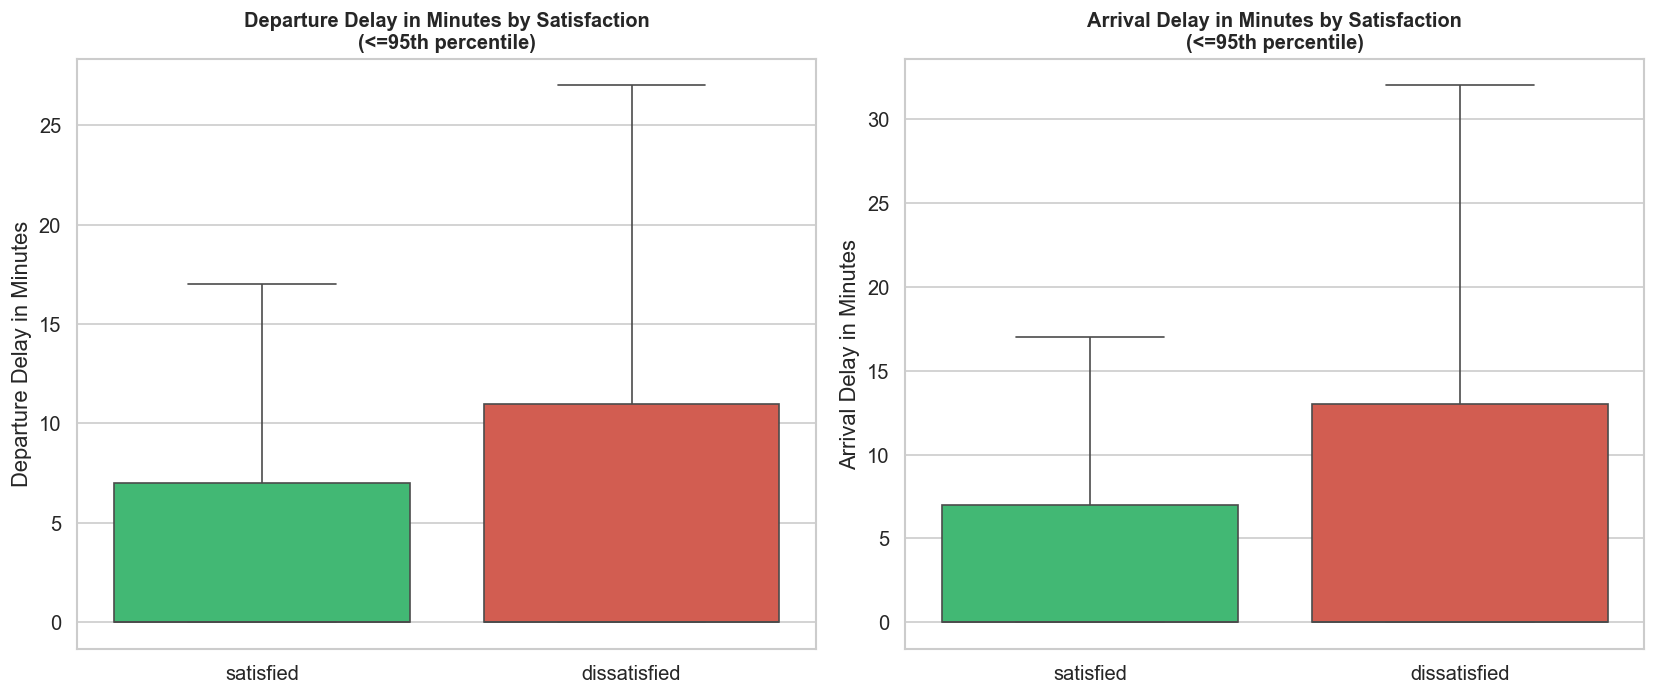

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, col in enumerate(DELAY_COLS):
    ax = axes[idx]
    temp = df[df[col] <= df[col].quantile(0.95)]
    sns.boxplot(data=temp, x='satisfaction', y=col, palette=SAT_PALETTE,
                order=['satisfied', 'dissatisfied'], ax=ax, showfliers=False)
    ax.set_title(f'{col} by Satisfaction\n(<=95th percentile)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('')

    for label in ['satisfied', 'dissatisfied']:
        subset = df[df['satisfaction'] == label][col]
        print(f'{col} | {label}: mean={subset.mean():.1f}, median={subset.median():.1f}')

plt.tight_layout()
plt.show()

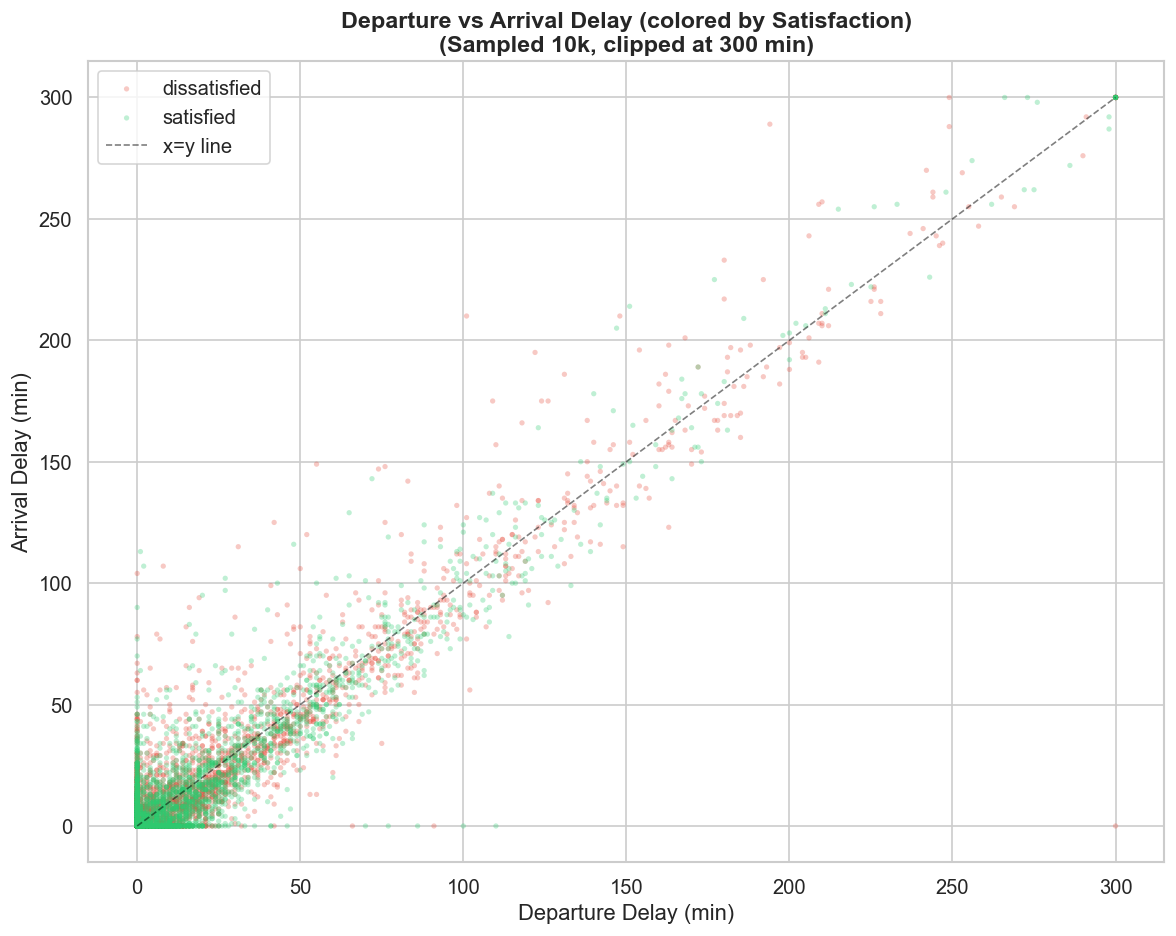

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))

sample = df.sample(n=10000, random_state=42)
sample_plot = sample.copy()
sample_plot['Departure Delay in Minutes'] = sample_plot['Departure Delay in Minutes'].clip(upper=300)
sample_plot['Arrival Delay in Minutes'] = sample_plot['Arrival Delay in Minutes'].clip(upper=300)

for label in ['dissatisfied', 'satisfied']:
    subset = sample_plot[sample_plot['satisfaction'] == label]
    ax.scatter(subset['Departure Delay in Minutes'], subset['Arrival Delay in Minutes'],
               c=SAT_PALETTE[label], label=label, alpha=0.3, s=10, edgecolors='none')

ax.plot([0, 300], [0, 300], 'k--', linewidth=1, alpha=0.5, label='x=y line')

ax.set_xlabel('Departure Delay (min)')
ax.set_ylabel('Arrival Delay (min)')
ax.set_title('Departure vs Arrival Delay (colored by Satisfaction)\n(Sampled 10k, clipped at 300 min)',
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Customer Segmentation Insights
Analyze satisfaction patterns across demographic and behavioral segments.

### 9.1 Age Group Analysis

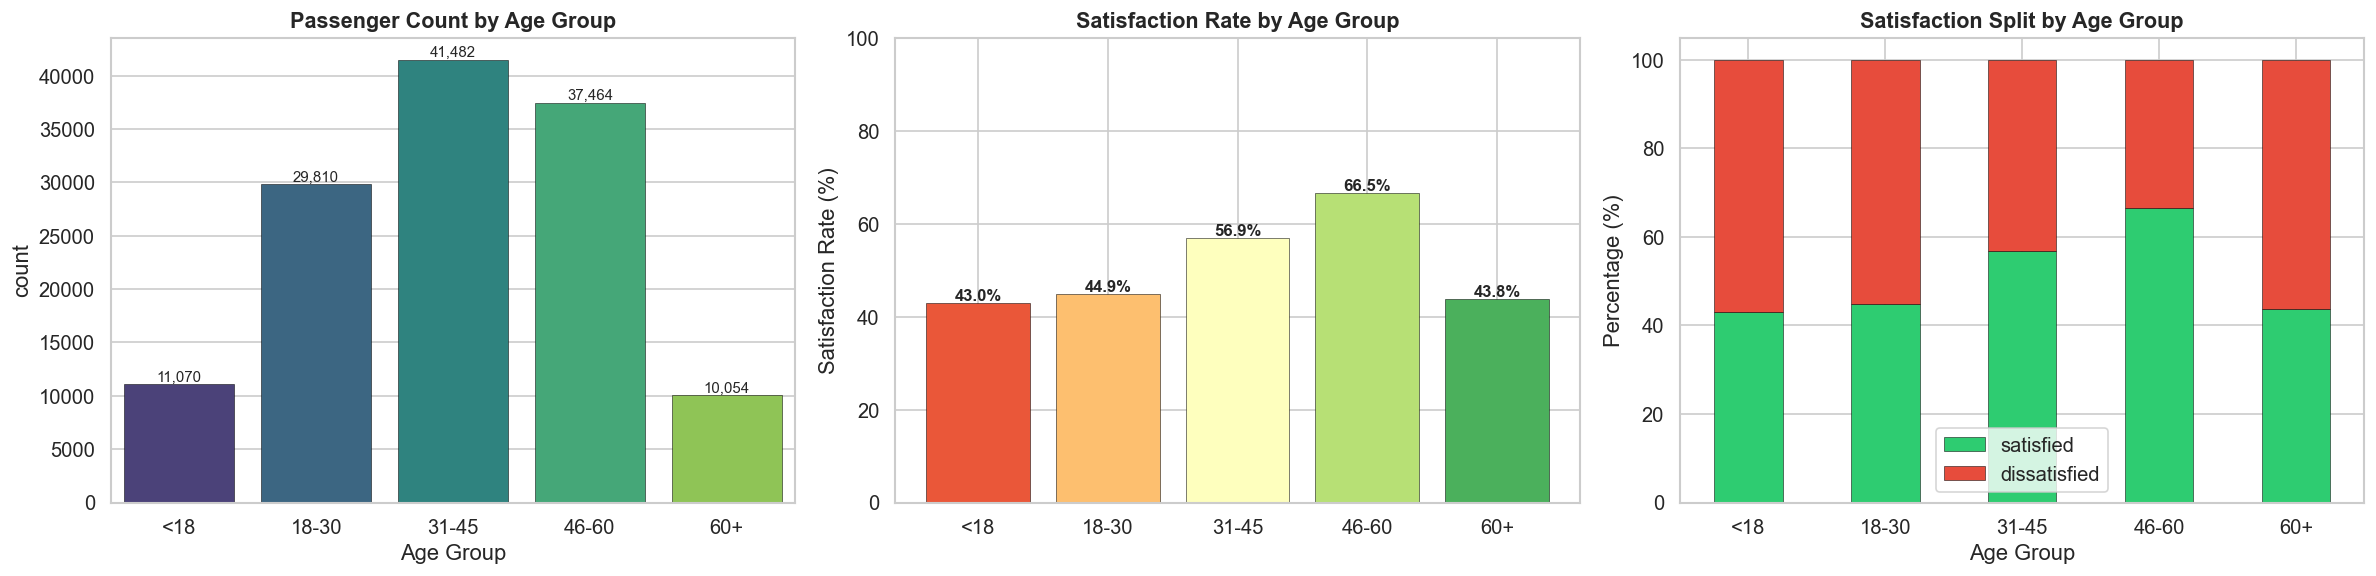

In [33]:
df['Age Group'] = pd.cut(df['Age'], bins=[0, 18, 30, 45, 60, 100],
                         labels=['<18', '18-30', '31-45', '46-60', '60+'])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax1 = axes[0]
sns.countplot(data=df, x='Age Group', palette='viridis', ax=ax1, edgecolor='black', linewidth=0.3)
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():,.0f}', (p.get_x()+p.get_width()/2., p.get_height()),
                 ha='center', va='bottom', fontsize=9)
ax1.set_title('Passenger Count by Age Group', fontsize=13, fontweight='bold')

ax2 = axes[1]
sat_rate = df.groupby('Age Group', observed=False)['satisfaction'].apply(
    lambda x: (x == 'satisfied').mean() * 100)
bars = ax2.bar(sat_rate.index.astype(str), sat_rate.values,
               color=sns.color_palette('RdYlGn', n_colors=5),
               edgecolor='black', linewidth=0.3)
for bar, val in zip(bars, sat_rate.values):
    ax2.text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5, f'{val:.1f}%',
             ha='center', fontsize=10, fontweight='bold')
ax2.set_title('Satisfaction Rate by Age Group', fontsize=13, fontweight='bold')
ax2.set_ylabel('Satisfaction Rate (%)')
ax2.set_ylim(0, 100)

ax3 = axes[2]
ct = pd.crosstab(df['Age Group'], df['satisfaction'], normalize='index') * 100
ct[['satisfied', 'dissatisfied']].plot(kind='bar', stacked=True, ax=ax3,
    color=[SAT_PALETTE['satisfied'], SAT_PALETTE['dissatisfied']],
    edgecolor='black', linewidth=0.3)
ax3.set_title('Satisfaction Split by Age Group', fontsize=13, fontweight='bold')
ax3.set_ylabel('Percentage (%)')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.legend(title='')

plt.tight_layout()
plt.show()

df.drop('Age Group', axis=1, inplace=True)

### 9.2 Loyal vs Disloyal Customer Patterns

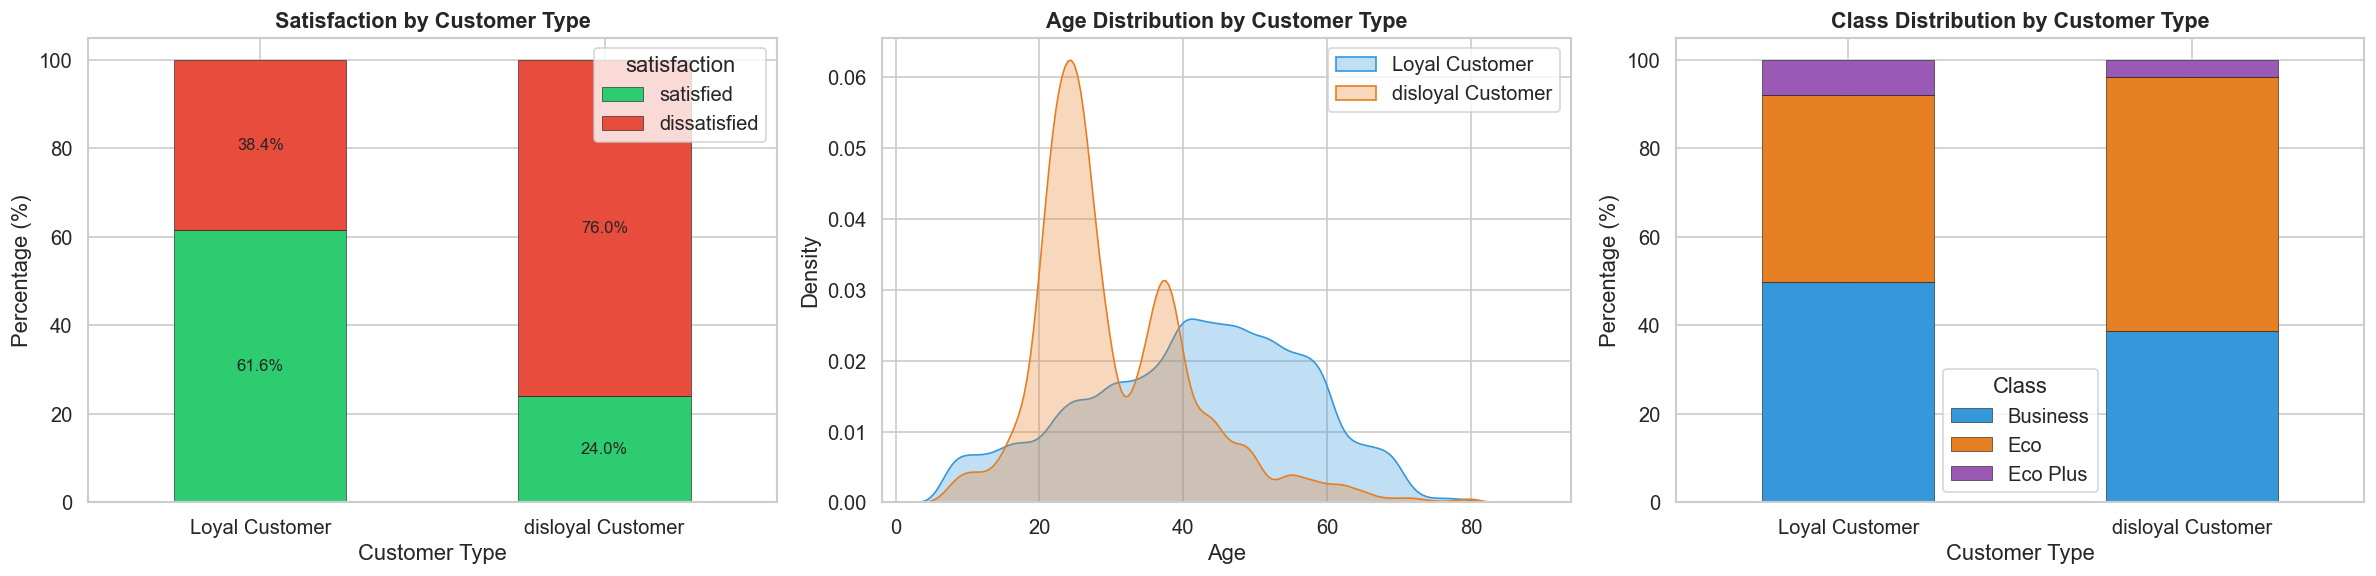

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax1 = axes[0]
ct = pd.crosstab(df['Customer Type'], df['satisfaction'], normalize='index') * 100
ct[['satisfied', 'dissatisfied']].plot(kind='bar', stacked=True, ax=ax1,
    color=[SAT_PALETTE['satisfied'], SAT_PALETTE['dissatisfied']],
    edgecolor='black', linewidth=0.3)
ax1.set_title('Satisfaction by Customer Type', fontsize=13, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.set_ylabel('Percentage (%)')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)

ax2 = axes[1]
for ctype, color in CUST_PALETTE.items():
    sns.kdeplot(df[df['Customer Type'] == ctype]['Age'], color=color,
                label=ctype, fill=True, alpha=0.3, ax=ax2)
ax2.set_title('Age Distribution by Customer Type', fontsize=13, fontweight='bold')
ax2.legend()

ax3 = axes[2]
ct2 = pd.crosstab(df['Customer Type'], df['Class'], normalize='index') * 100
ct2.plot(kind='bar', stacked=True, ax=ax3, color=list(CLASS_PALETTE.values()),
         edgecolor='black', linewidth=0.3)
ax3.set_title('Class Distribution by Customer Type', fontsize=13, fontweight='bold')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.set_ylabel('Percentage (%)')
ax3.legend(title='Class')

plt.tight_layout()
plt.show()

### 9.3 Business vs Personal Travel Patterns

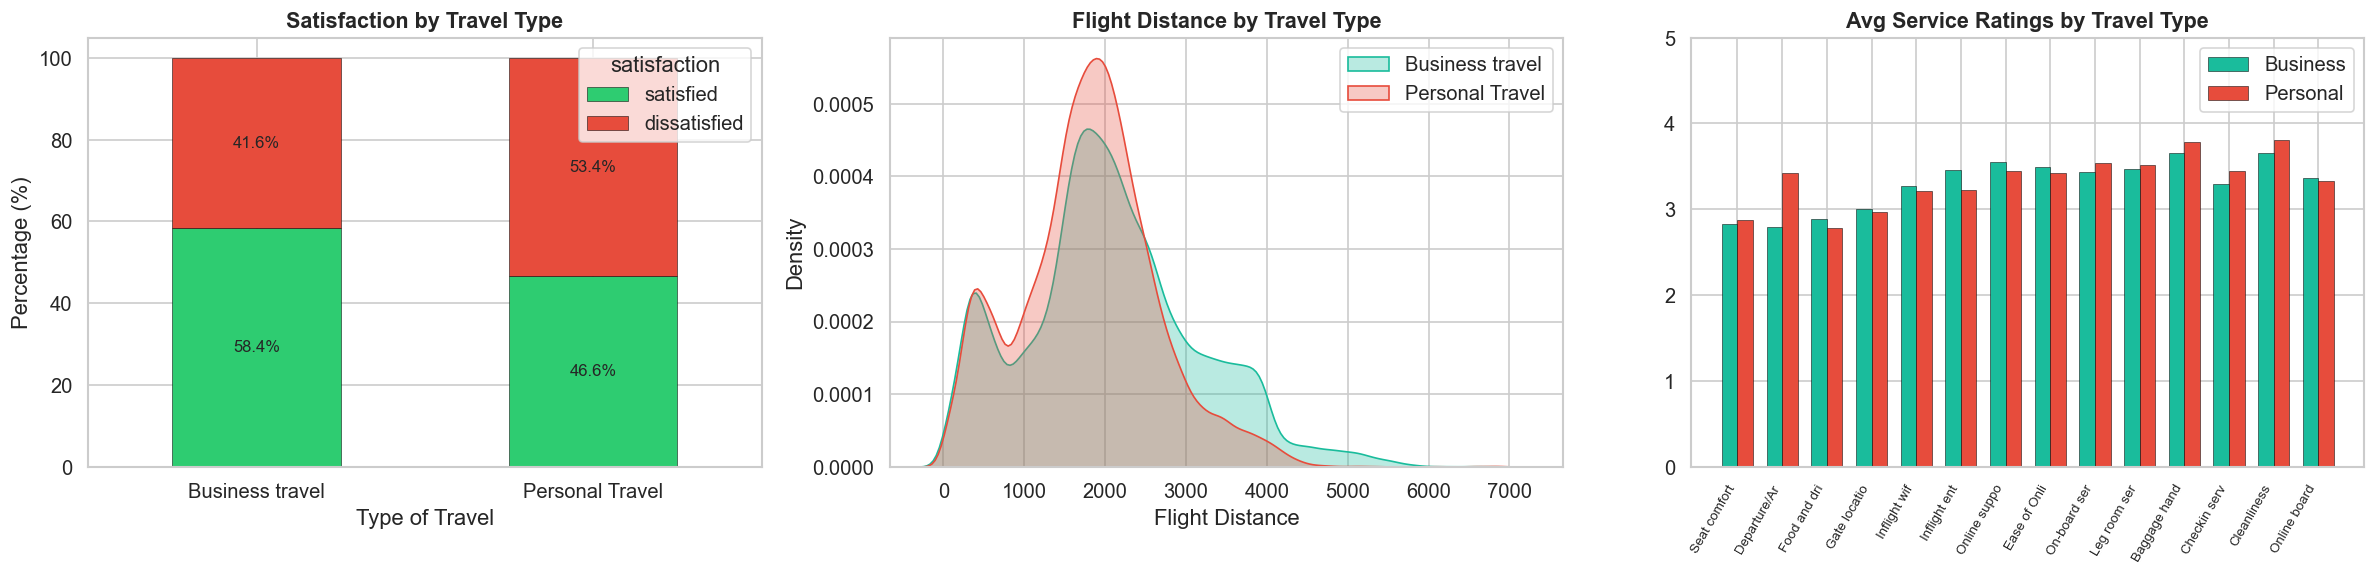

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax1 = axes[0]
ct = pd.crosstab(df['Type of Travel'], df['satisfaction'], normalize='index') * 100
ct[['satisfied', 'dissatisfied']].plot(kind='bar', stacked=True, ax=ax1,
    color=[SAT_PALETTE['satisfied'], SAT_PALETTE['dissatisfied']],
    edgecolor='black', linewidth=0.3)
ax1.set_title('Satisfaction by Travel Type', fontsize=13, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.set_ylabel('Percentage (%)')
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)

ax2 = axes[1]
for ttype, color in TRAVEL_PALETTE.items():
    sns.kdeplot(df[df['Type of Travel'] == ttype]['Flight Distance'], color=color,
                label=ttype, fill=True, alpha=0.3, ax=ax2)
ax2.set_title('Flight Distance by Travel Type', fontsize=13, fontweight='bold')
ax2.legend()

ax3 = axes[2]
travel_means = df.groupby('Type of Travel')[SERVICE_COLS].mean()
x = np.arange(len(SERVICE_COLS))
width = 0.35
ax3.bar(x - width/2, travel_means.loc['Business travel'], width,
        label='Business', color=TRAVEL_PALETTE['Business travel'],
        edgecolor='black', linewidth=0.3)
ax3.bar(x + width/2, travel_means.loc['Personal Travel'], width,
        label='Personal', color=TRAVEL_PALETTE['Personal Travel'],
        edgecolor='black', linewidth=0.3)
ax3.set_xticks(x)
ax3.set_xticklabels([c[:12] for c in SERVICE_COLS], rotation=60, ha='right', fontsize=8)
ax3.set_title('Avg Service Ratings by Travel Type', fontsize=13, fontweight='bold')
ax3.legend()
ax3.set_ylim(0, 5)

plt.tight_layout()
plt.show()


## 10. Key Findings & Summary

### Dataset Overview
- **129,880** passenger survey responses, **22** features
- Only **393** nulls (in `Arrival Delay in Minutes`) — very clean dataset
- Target is mildly imbalanced: **~54.7% satisfied**, **~45.3% dissatisfied**

---

### Key Findings

**1. Customer Profile Matters**
- **Loyal Customers** make up ~81.7% and have higher satisfaction rates than disloyal customers
- **Business travelers** (~69.1%) show markedly different satisfaction patterns vs personal travelers
- **Business class** passengers report the highest satisfaction; **Eco** the lowest

**2. Age Patterns**
- Middle-aged passengers (40-60) tend to show higher satisfaction
- Younger (<18) and elderly (60+) may have distinct service expectations

**3. Service Ratings are the Strongest Predictors**
- **Online boarding**, **Inflight entertainment**, and **Inflight wifi service** show the highest correlation with satisfaction
- **Gate location** and **Departure/Arrival time convenient** show weaker associations

**4. Delays Have Modest Impact**
- Delay distributions are heavily right-skewed (most flights have zero delay)
- Delays alone do not strongly differentiate satisfied from dissatisfied — service quality matters more

**5. Segment Interactions**
- Business travelers in Business class have the highest satisfaction rates
- Personal travelers in Economy show the lowest satisfaction rates


